This document will be used to produce figures that I will use in my final 4YP report. 

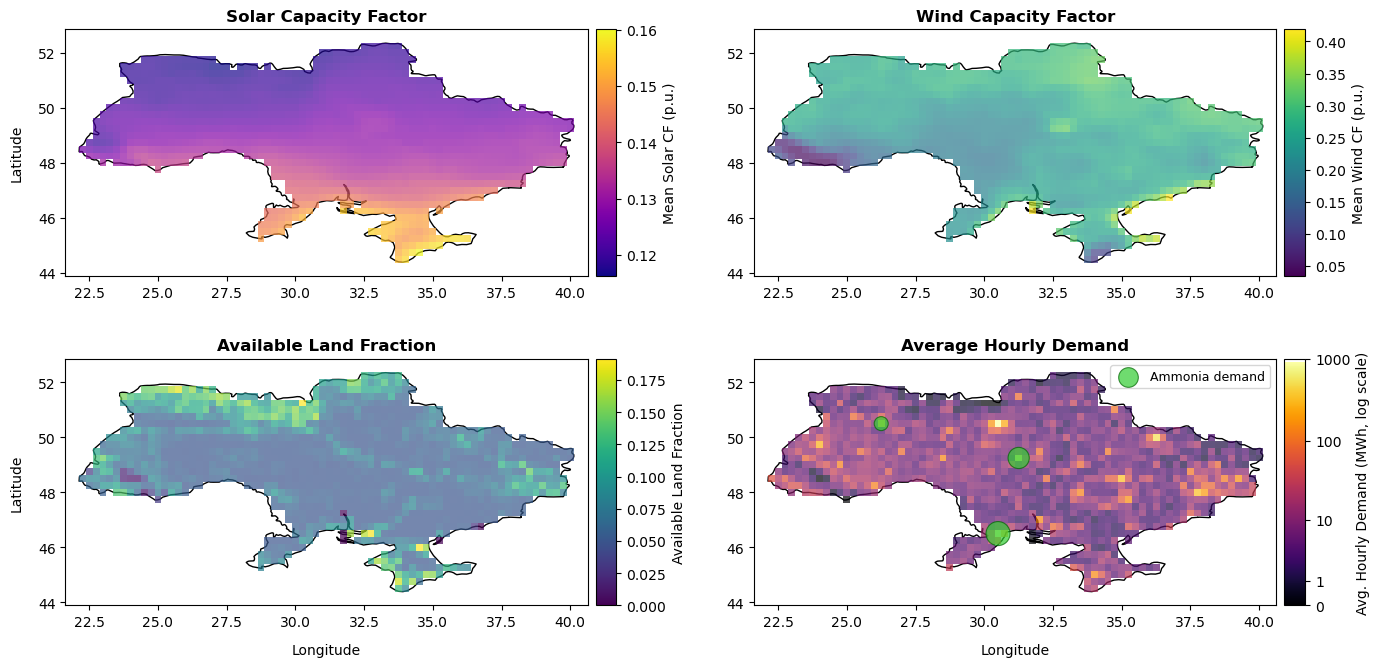

In [21]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from shapely.geometry import box
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ── Load data ──
attrs = pd.read_csv("data_prep/data/UKR_attributes_3.csv")
outline = gpd.read_file("data_prep/data/ukraine_merged_dissolved_noholes.geojson")

# Build 0.25° cell geometries
half = 0.125
attrs["geometry"] = attrs.apply(
    lambda r: box(r["lon"] - half, r["lat"] - half, r["lon"] + half, r["lat"] + half), axis=1
)
gdf = gpd.GeoDataFrame(attrs, geometry="geometry", crs="EPSG:4326")

# Log-transformed demand column
gdf["log_demand"] = np.log1p(gdf["avg_equiv_demand_MWh"])

# Ammonia sites (non-zero demand only)
ammonia = attrs[attrs["ammonia_demand_tonne"] > 0].copy()

# ── Figure setup ──
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.subplots_adjust(hspace=0.15, wspace=0.25)

plot_configs = [
    {"ax": axes[0, 0], "col": "solar_cf_mean",          "cmap": "plasma",  "label": "Mean Solar CF (p.u.)",     "title": "Solar Capacity Factor",    "log": False},
    {"ax": axes[0, 1], "col": "wind_cf_mean",           "cmap": "viridis", "label": "Mean Wind CF (p.u.)",      "title": "Wind Capacity Factor",     "log": False},
    {"ax": axes[1, 0], "col": "available_land_fraction", "cmap": "viridis", "label": "Available Land Fraction",  "title": "Available Land Fraction",  "log": False},
    {"ax": axes[1, 1], "col": "log_demand",             "cmap": "inferno", "label": "Avg. Hourly Demand (MWh, log scale)", "title": "Average Hourly Demand",    "log": True},
]

for cfg in plot_configs:
    ax = cfg["ax"]
    col = cfg["col"]

    # Plot outline
    outline.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.0, zorder=0)

    # Plot cells
    gdf.plot(column=col, cmap=cfg["cmap"], ax=ax, alpha=0.7, edgecolor="none", legend=False)

    # Colorbar pinned to subplot height
    norm = mcolors.Normalize(vmin=gdf[col].min(), vmax=gdf[col].max())
    sm = plt.cm.ScalarMappable(cmap=cfg["cmap"], norm=norm)
    sm.set_array([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)
    cbar = fig.colorbar(sm, cax=cax)

    if cfg["log"]:
        # Choose nice MWh values as powers of 10
        mwh_ticks = [0, 1, 10, 100, 1000]
        log_ticks = [np.log1p(v) for v in mwh_ticks]
        cbar.set_ticks(log_ticks)
        cbar.set_ticklabels(mwh_ticks)
        cbar.set_label(cfg["label"], fontsize=10)
    else:
        cbar.set_label(cfg["label"], fontsize=10)

    ax.set_title(cfg["title"], fontsize=12, fontweight="bold")
    ax.set_xlim(outline.total_bounds[0] - 0.5, outline.total_bounds[2] + 0.5)
    ax.set_ylim(outline.total_bounds[1] - 0.5, outline.total_bounds[3] + 0.5)
    ax.set_aspect("equal")
    row, col_idx = np.argwhere(axes == ax)[0]
    ax.set_xlabel("Longitude" if row == 1 else "", labelpad=10)
    ax.set_ylabel("Latitude" if col_idx == 0 else "", labelpad=10)

# ── Overlay ammonia circles on demand subplot ──
ax_demand = axes[1, 1]
max_size = 300
sizes = ammonia["ammonia_demand_tonne"] / ammonia["ammonia_demand_tonne"].max() * max_size
ax_demand.scatter(
    ammonia["lon"], ammonia["lat"],
    s=sizes, c="limegreen", edgecolors="darkgreen", linewidths=0.8,
    alpha=0.7, zorder=5, label="Ammonia demand"
)
ax_demand.legend(loc="upper right", fontsize=9)

plt.savefig("4YP_Figures/2x2_attributes.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
print(f"Max avg_equiv_demand_MWh: {attrs['avg_equiv_demand_MWh'].max():.1f}")

Max avg_equiv_demand_MWh: 924.2


In [3]:
import pandas as pd
import numpy as np

attrs = pd.read_csv("data_prep/data/UKR_attributes_3.csv")
for col in ["pc1", "pc2"]:
    print(f"{col}: min={attrs[col].min():.2f}, max={attrs[col].max():.2f}, "
          f"mean={attrs[col].mean():.2f}, std={attrs[col].std():.2f}")

# Symmetric range that would cover both
shared_abs = max(attrs["pc1"].abs().max(), attrs["pc2"].abs().max())
print(f"\nShared symmetric range: [-{shared_abs:.2f}, +{shared_abs:.2f}]")

pc1: min=-91.81, max=112.11, mean=0.00, std=58.92
pc2: min=-92.34, max=90.15, mean=0.00, std=42.28

Shared symmetric range: [-112.11, +112.11]


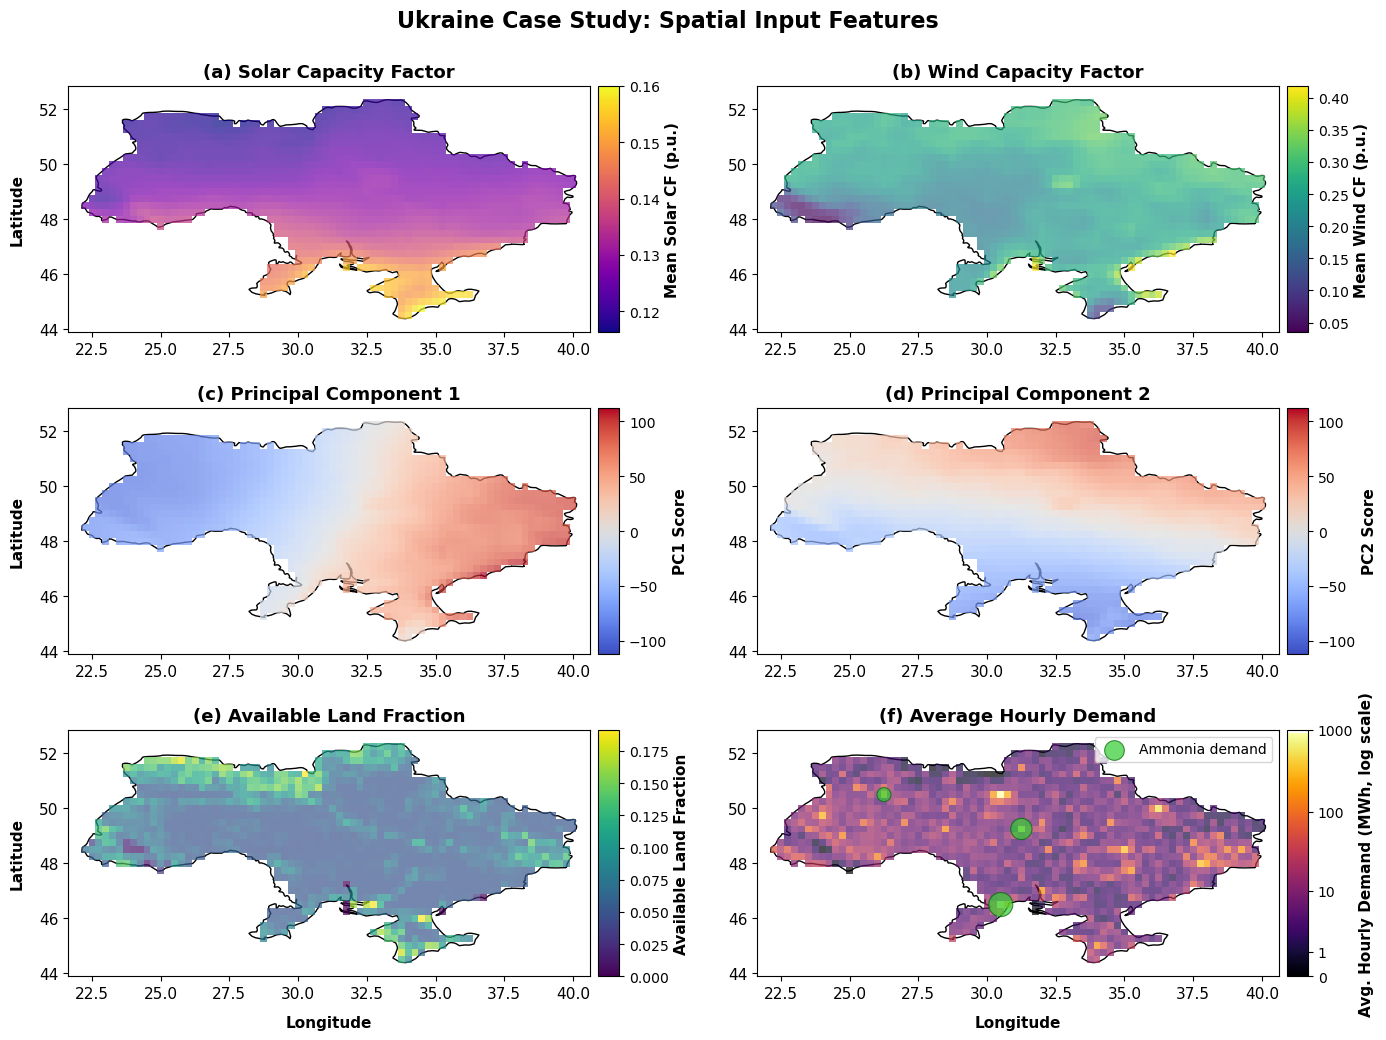

In [14]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from shapely.geometry import box
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ── Load data ──
attrs = pd.read_csv("data_prep/data/UKR_attributes_3.csv")
outline = gpd.read_file("data_prep/data/ukraine_merged_dissolved_noholes.geojson")

# Build 0.25° cell geometries
half = 0.125
attrs["geometry"] = attrs.apply(
    lambda r: box(r["lon"] - half, r["lat"] - half, r["lon"] + half, r["lat"] + half), axis=1
)
gdf = gpd.GeoDataFrame(attrs, geometry="geometry", crs="EPSG:4326")

# Log-transformed demand column
gdf["log_demand"] = np.log1p(gdf["avg_equiv_demand_MWh"])

# Ammonia sites (non-zero demand only)
ammonia = attrs[attrs["ammonia_demand_tonne"] > 0].copy()

# Shared symmetric range for PCs
pc_abs_max = max(gdf["pc1"].abs().max(), gdf["pc2"].abs().max())

# ── Figure setup ──
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.subplots_adjust(hspace=0.15, wspace=0.25)

plot_configs = [
    {"ax": axes[0, 0], "col": "solar_cf_mean",          "cmap": "plasma",   "label": "Mean Solar CF (p.u.)",                    "title": "(a) Solar Capacity Factor",    "log": False, "shared_norm": None},
    {"ax": axes[0, 1], "col": "wind_cf_mean",           "cmap": "viridis",  "label": "Mean Wind CF (p.u.)",                     "title": "(b) Wind Capacity Factor",     "log": False, "shared_norm": None},
    {"ax": axes[1, 0], "col": "pc1",                    "cmap": "coolwarm", "label": "PC1 Score",                               "title": "(c) Principal Component 1",    "log": False, "shared_norm": mcolors.Normalize(vmin=-pc_abs_max, vmax=pc_abs_max)},
    {"ax": axes[1, 1], "col": "pc2",                    "cmap": "coolwarm", "label": "PC2 Score",                               "title": "(d) Principal Component 2",    "log": False, "shared_norm": mcolors.Normalize(vmin=-pc_abs_max, vmax=pc_abs_max)},
    {"ax": axes[2, 0], "col": "available_land_fraction", "cmap": "viridis", "label": "Available Land Fraction",                 "title": "(e) Available Land Fraction",  "log": False, "shared_norm": None},
    {"ax": axes[2, 1], "col": "log_demand",             "cmap": "inferno",  "label": "Avg. Hourly Demand (MWh, log scale)",     "title": "(f) Average Hourly Demand",    "log": True,  "shared_norm": None},
]

for cfg in plot_configs:
    ax = cfg["ax"]
    col = cfg["col"]

    # Plot outline
    outline.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.0, zorder=0)

    # Determine norm
    norm = cfg["shared_norm"] if cfg["shared_norm"] is not None else mcolors.Normalize(vmin=gdf[col].min(), vmax=gdf[col].max())

    # Plot cells
    gdf.plot(column=col, cmap=cfg["cmap"], norm=norm, ax=ax, alpha=0.7, edgecolor="none", legend=False)

    # Colorbar pinned to subplot height
    sm = plt.cm.ScalarMappable(cmap=cfg["cmap"], norm=norm)
    sm.set_array([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)
    cbar = fig.colorbar(sm, cax=cax)

    if cfg["log"]:
        mwh_ticks = [0, 1, 10, 100, 1000]
        log_ticks = [np.log1p(v) for v in mwh_ticks]
        cbar.set_ticks(log_ticks)
        cbar.set_ticklabels(mwh_ticks)
        cbar.set_label(cfg["label"], fontsize=11, fontweight="bold")
    else:
        cbar.set_label(cfg["label"], fontsize=11, fontweight="bold")

    ax.set_title(cfg["title"], fontsize=13, fontweight="bold")
    ax.set_xlim(outline.total_bounds[0] - 0.5, outline.total_bounds[2] + 0.5)
    ax.set_ylim(outline.total_bounds[1] - 0.5, outline.total_bounds[3] + 0.5)
    ax.set_aspect("equal")
    row, col_idx = np.argwhere(axes == ax)[0]
    ax.set_xlabel("Longitude" if row == 2 else "", labelpad=10, fontsize=11, fontweight="bold")
    ax.set_ylabel("Latitude" if col_idx == 0 else "", labelpad=10, fontsize=11, fontweight="bold")
    ax.tick_params(axis='both', labelsize=11)

# ── Overlay ammonia circles on demand subplot ──
ax_demand = axes[2, 1]
max_size = 300
sizes = ammonia["ammonia_demand_tonne"] / ammonia["ammonia_demand_tonne"].max() * max_size
ax_demand.scatter(
    ammonia["lon"], ammonia["lat"],
    s=sizes, c="limegreen", edgecolors="darkgreen", linewidths=0.8,
    alpha=0.7, zorder=5, label="Ammonia demand"
)
ax_demand.legend(loc="upper right", fontsize=10)

plt.suptitle("Ukraine Case Study: Spatial Input Features", fontsize=16, fontweight="bold", y=0.93)

plt.savefig("4YP_Figures/3x2_attributes.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\Benhd\AppData\Local\Temp\ipykernel_2376\1182467014.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab20")
C:\Users\Benhd\AppData\Local\Temp\ipykernel_2376\1182467014.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab20")
C:\Users\Benhd\AppData\Local\Temp\ipykernel_2376\1182467014.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab20")
C:\Users\Benhd\A

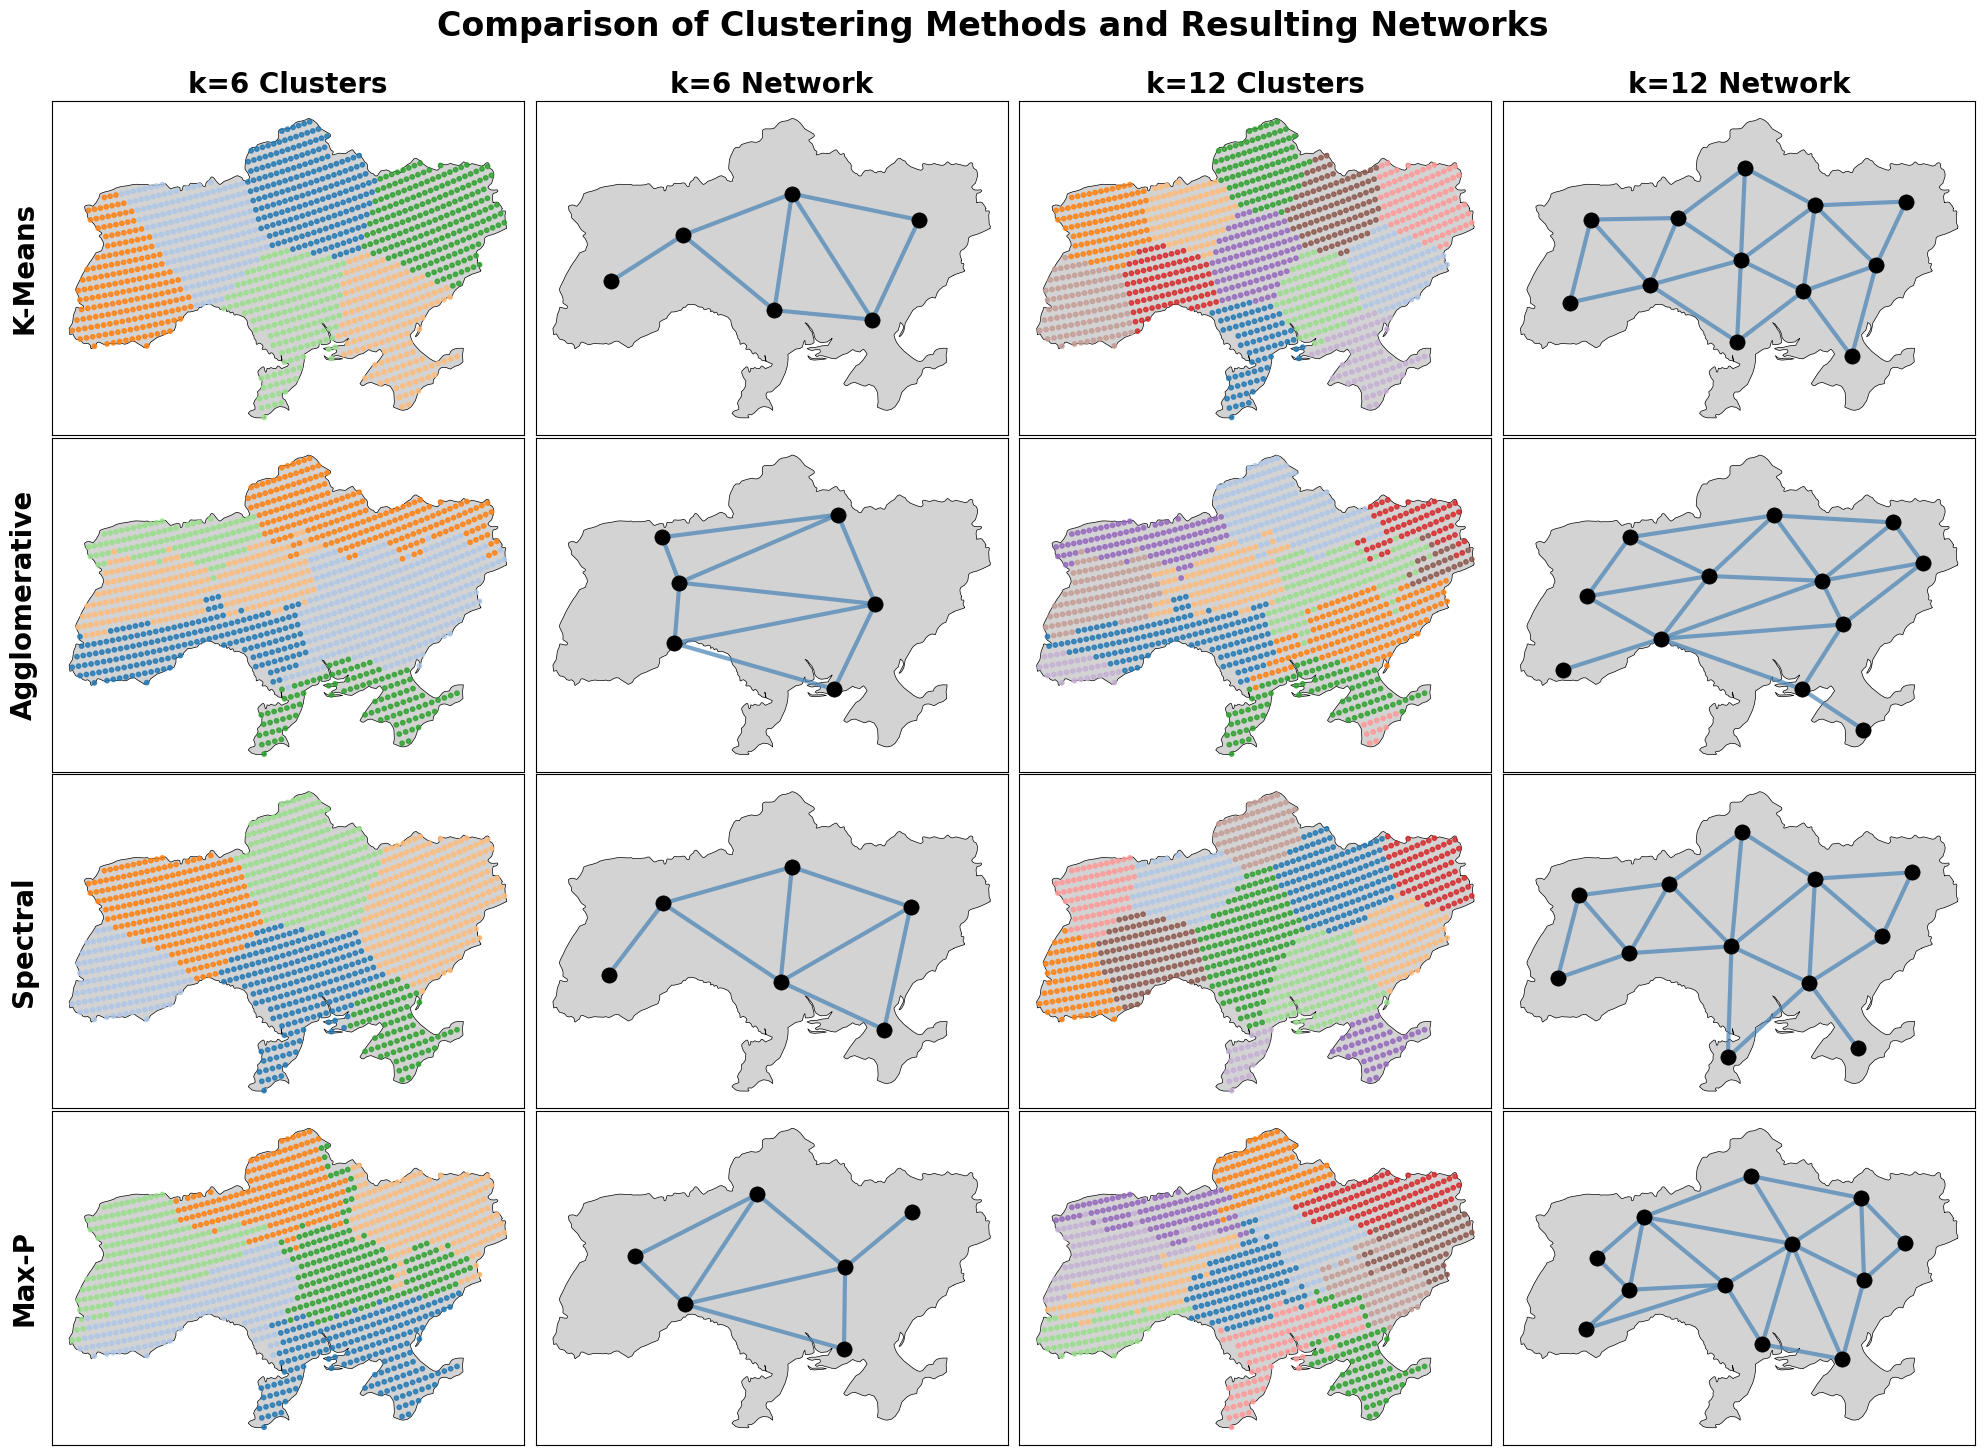

Saved to 4YP_Figures\cluster_network_comparison_k6_k12.png


In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from pathlib import Path

# ── paths ──
BASE = Path(".")
DATA = BASE / "data_prep" / "data"
CLUST = BASE / "data_prep" / "Clustering_Output" / "KNN_Graph_output" / "nodal_ammonia_bidirectional"
OUT = BASE / "4YP_Figures" / "cluster_network_comparison_k6_k12.png"

# ── load shared geodata ──
ukr_boundary = gpd.read_file(DATA / "ukraine_merged_dissolved_noholes.geojson").to_crs("EPSG:3035")

attrs = pd.read_csv(DATA / "UKR_attributes_3.csv")
attrs["cell_id"] = attrs["lat"].astype(str) + "_" + attrs["lon"].astype(str)
cell_gdf = gpd.GeoDataFrame(
    attrs, geometry=gpd.points_from_xy(attrs["lon"], attrs["lat"], crs="EPSG:4326")
).to_crs("EPSG:3035")
cell_gdf["cx"] = cell_gdf.geometry.x
cell_gdf["cy"] = cell_gdf.geometry.y
cell_gdf = cell_gdf.set_index("cell_id")

xmin, ymin, xmax, ymax = ukr_boundary.total_bounds
pad = 50_000
xlim = (xmin - pad, xmax + pad)
ylim = (ymin - pad, ymax + pad)

# ── config ──
methods = {
    "K-Means": "KMeans_Spatial",
    "Agglomerative": "Agglomerative",
    "Spectral": "Spectral",
    "Max-P": "MaxP_Rook",
}
k_values = [6, 12]
NODE_SIZE = 120

# ── figure ──
fig, axes = plt.subplots(4, 4, figsize=(20, 14.5))

for row, (method_label, method_dir) in enumerate(methods.items()):
    for ki, k in enumerate(k_values):
        col_clust = ki * 2
        col_net   = ki * 2 + 1
        folder = CLUST / method_dir / f"{method_dir}_k{k}"

        # ── cluster map panel ──
        ax = axes[row, col_clust]
        mapping = pd.read_csv(folder / "cell_to_cluster_mapping.csv", index_col=0)
        merged = cell_gdf.join(mapping, how="inner")
        labels = merged["cluster"].values
        cx = merged["cx"].values
        cy = merged["cy"].values

        unique = np.sort(np.unique(labels))
        n_clusters = len(unique)
        base_cmap = plt.cm.get_cmap("tab20")
        colors = [base_cmap(i % 20) for i in range(n_clusters)]
        cmap = mcolors.ListedColormap(colors)
        norm = mcolors.Normalize(vmin=unique.min() - 0.5, vmax=unique.max() + 0.5)

        ukr_boundary.plot(ax=ax, facecolor="lightgrey", edgecolor="black", linewidth=0.5)
        ax.scatter(cx, cy, c=labels, cmap=cmap, norm=norm, s=10, alpha=0.8, zorder=2)

        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])

        # ── network panel ──
        ax = axes[row, col_net]
        meta = pd.read_csv(folder / "cluster_metadata.csv", index_col=0)
        links = pd.read_csv(folder / "reduced_links.csv", index_col=0)

        pts = gpd.GeoDataFrame(
            meta, geometry=gpd.points_from_xy(meta["lon"], meta["lat"], crs="EPSG:4326")
        ).to_crs("EPSG:3035")
        meta["x"] = pts.geometry.x
        meta["y"] = pts.geometry.y
        coord_map = meta.set_index("cluster_id")[["x", "y"]]

        segments = []
        for _, lnk in links.iterrows():
            a, b = int(lnk["cluster_a"]), int(lnk["cluster_b"])
            if a in coord_map.index and b in coord_map.index:
                pa, pb = coord_map.loc[a], coord_map.loc[b]
                segments.append([(pa["x"], pa["y"]), (pb["x"], pb["y"])])

        ukr_boundary.plot(ax=ax, facecolor="lightgrey", edgecolor="black", linewidth=0.5)
        if segments:
            lc = LineCollection(segments, colors="steelblue", linewidths=3, alpha=0.7, zorder=2)
            ax.add_collection(lc)

        ax.scatter(
            meta["x"], meta["y"], s=NODE_SIZE, c="black",
            edgecolors="black", linewidths=0.5, zorder=3,
        )

        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])

# ── row & column labels ──
for row, label in enumerate(methods.keys()):
    axes[row, 0].set_ylabel(label, fontsize=20, fontweight="bold", rotation=90, labelpad=10)

col_titles = ["k=6 Clusters", "k=6 Network", "k=12 Clusters", "k=12 Network"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=20, fontweight="bold")

plt.suptitle("Comparison of Clustering Methods and Resulting Networks", fontsize=24, fontweight="bold", y=1)
plt.tight_layout(h_pad=0.5, w_pad=0.5)
fig.savefig(OUT, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to {OUT}")

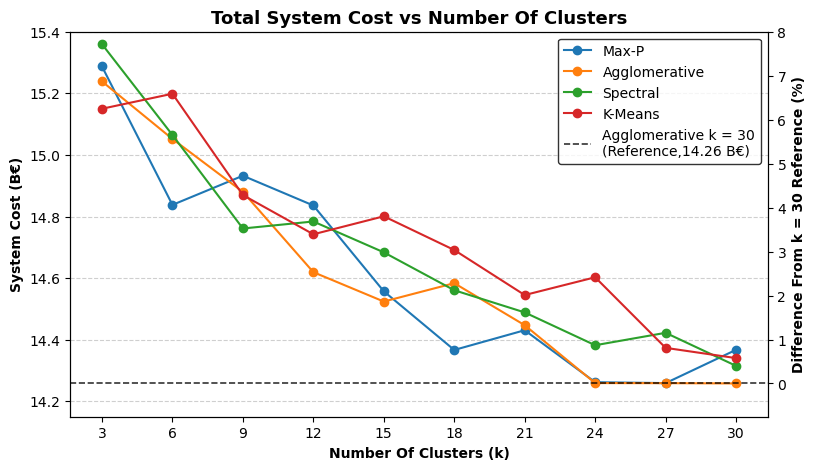

In [5]:
import calliope
import gc
import numpy as np
import matplotlib.pyplot as plt

# ── Config ──
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

colours = {
    'MaxP_Rook': '#1f77b4',
    'Agglomerative': '#ff7f0e',
    'Spectral': '#2ca02c',
    'KMeans_Spatial': '#d62728',
}
labels = {
    'MaxP_Rook': 'Max-P',
    'Agglomerative': 'Agglomerative',
    'Spectral': 'Spectral',
    'KMeans_Spatial': 'K-Means',
}

# ── Load costs ──
costs = {m: {} for m in methods}
for method in methods:
    for k in ks:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        model = calliope.read_netcdf(path)
        costs[method][k] = float(model.results.cost.sum())  # k€
        del model
        gc.collect()

# k=30 baseline
ref_path = f"{base_dir}/Agglomerative/Agglomerative_k30/weighted_percentile_timeseries/Agglomerative_weighted_k30_bidirectional.nc"
ref_model = calliope.read_netcdf(ref_path)
ref_cost = float(ref_model.results.cost.sum())  # k€
del ref_model
gc.collect()

# ── Plot ──
fig, ax = plt.subplots(figsize=(9, 5))

for method in methods:
    vals_be = [costs[method][k] / 1e6 for k in ks]
    ax.plot(ks, vals_be, marker='o', markersize=6, color=colours[method], label=labels[method])

# Baseline
ref_be = ref_cost / 1e6
ax.axhline(ref_be, color='black', linestyle='--', linewidth=1.2, alpha=0.8, label=f'Agglomerative k = 30\n(Reference,{ref_be:.2f} B€)')

ax.set_xlabel('Number Of Clusters (k)', fontweight='bold')
ax.set_ylabel('System Cost (B€)', fontweight='bold')
ax.set_xticks(ks)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.set_title('Total System Cost vs Number Of Clusters', fontsize=13, fontweight='bold')
leg = ax.legend()
leg.get_frame().set_edgecolor('black')
ax.set_ylim(14.15, 15.4)

# ── Aligned right axis ──
ax2 = ax.twinx()
y_lo, y_hi = ax.get_ylim()
ax2.set_ylim(((y_lo - ref_be) / ref_be) * 100, ((y_hi - ref_be) / ref_be) * 100)
ax2.set_ylabel('Difference From k = 30 Reference (%)', fontweight='bold')

plt.savefig('4YP_Figures/system_cost_dual_axis_k3_k30.png', dpi=300, bbox_inches='tight')
plt.show()

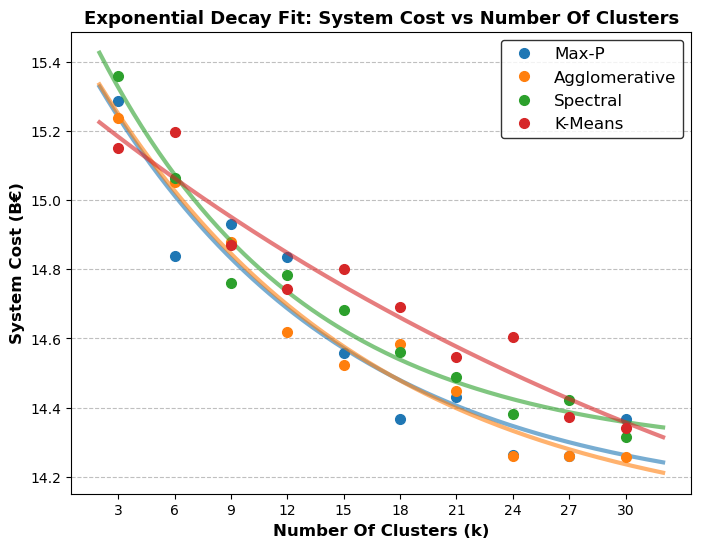

       Method       R2   lambda  C_inf_BE
        Max-P 0.907270 0.075142 14.113639
Agglomerative 0.971347 0.068107 14.043769
     Spectral 0.971712 0.090533 14.265567
      K-Means 0.926044 0.023683 13.433078


In [8]:
import os, gc, numpy as np, calliope, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ── Config ──
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means'}

# ── Load costs ──
records = []
for method in methods:
    for k in ks:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue
        model = calliope.read_netcdf(path)
        records.append({'method': method, 'k': k, 'cost': float(model.results.cost.sum())})
        del model; gc.collect()

df = pd.DataFrame(records)

ref_path = f"{base_dir}/KMeans_Spatial/KMeans_Spatial_k30/weighted_percentile_timeseries/KMeans_Spatial_weighted_k30_bidirectional.nc"
ref_model = calliope.read_netcdf(ref_path)
ref_cost = float(ref_model.results.cost.sum())
del ref_model; gc.collect()

# ── Decay model ──
def decay_model_3p(k, A, lam, C_inf):
    return C_inf + A * np.exp(-lam * k)

# ── Figure ──
fig, ax = plt.subplots(figsize=(8, 6))

k_smooth = np.linspace(2, 32, 200)
param_rows = []

for method in methods:
    sub = df[df['method'] == method].sort_values('k')
    k_data = sub['k'].values.astype(float)
    c_data = sub['cost'].values / 1e6  # B€

    # Data points
    ax.plot(k_data, c_data, marker='o', markersize=7, linestyle='none',
            color=colours[method], label=labels[method])

    # Fit
    p0 = [c_data.max() - c_data.min(), 0.1, c_data.min()]
    popt, _ = curve_fit(decay_model_3p, k_data, c_data, p0=p0, maxfev=10000)
    A, lam, C_inf = popt

    # R²
    y_pred = decay_model_3p(k_data, *popt)
    ss_res = np.sum((c_data - y_pred) ** 2)
    ss_tot = np.sum((c_data - c_data.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    # Smooth curve
    ax.plot(k_smooth, decay_model_3p(k_smooth, *popt), linewidth=3, alpha=0.6,
            color=colours[method])

    param_rows.append({'Method': labels[method], 'R2': r2, 'lambda': lam, 'C_inf_BE': C_inf})


ax.set_xlabel('Number Of Clusters (k)', fontweight='bold', fontsize=12)
ax.set_ylabel('System Cost (B€)', fontweight='bold', fontsize=12)
ax.set_xticks(ks)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.8)
ax.set_axisbelow(True)
ax.set_title('Exponential Decay Fit: System Cost vs Number Of Clusters', fontsize=13, fontweight='bold')
leg = ax.legend(fontsize=12)
leg.get_frame().set_edgecolor('black')

plt.savefig('4YP_Figures/system_cost_decay_fit_k3_k30.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Save parameter table ──
params_df = pd.DataFrame(param_rows)
params_df.to_csv('4YP_Figures/decay_fit_params_k3_k30.csv', index=False)
print(params_df.to_string(index=False))

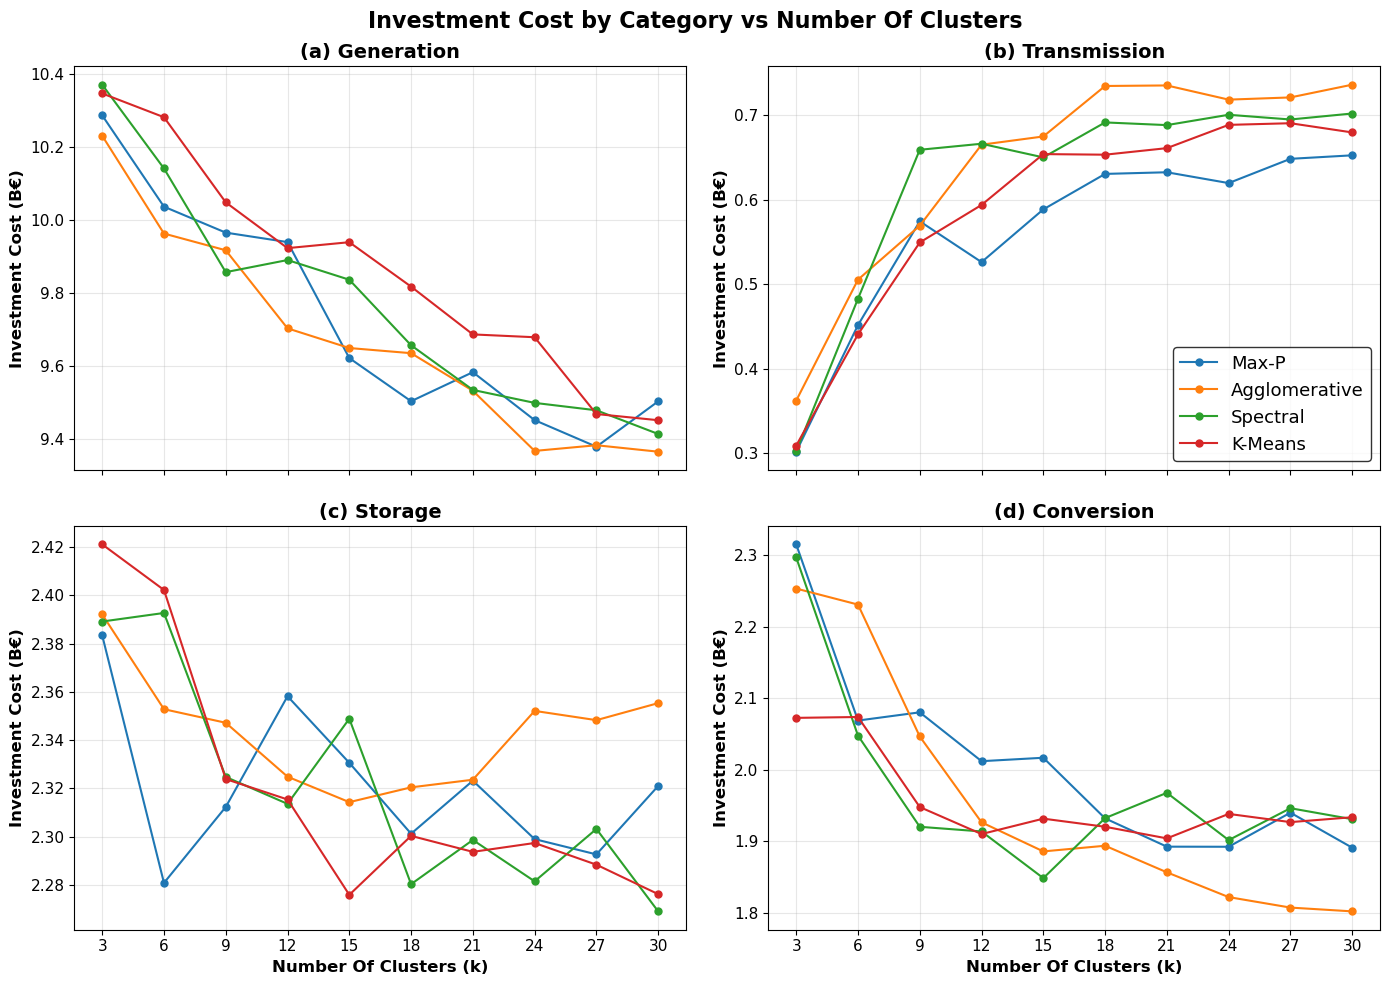

In [9]:
import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt

# ── Config ──
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

generation_techs   = ['solar_single_axis', 'onshore_wind', 'offshore_wind']
transmission_techs = ['dc_transmission', 'hydrogen_pipeline', 'ammonia_pipeline', 'methane_pipeline']
storage_techs      = ['battery', 'compressed_hydrogen_storage', 'cavern_hydrogen_storage', 'ammonia_storage']
conversion_techs   = ['fuel_cell', 'electrolyser', 'ammonia_ccgt', 'hydrogen_ccgt', 'haber_and_air_separation']

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means'}

# ── Load investment costs ──
all_records = {m: [] for m in methods}

for method in methods:
    for k in ks:
        nc_path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(nc_path):
            print(f"Missing: {nc_path}")
            continue

        model = calliope.read_netcdf(nc_path)
        cost_invest = model.results['cost_investment'].to_dataframe().reset_index()
        cost_invest['tech'] = cost_invest['loc_techs_investment_cost'].str.split('::').str[-1].str.split(':').str[0]
        tech_investment = cost_invest.groupby('tech')['cost_investment'].sum()

        row = {'k': k}
        row['generation']   = sum(tech_investment.get(t, 0) for t in generation_techs)
        row['transmission'] = sum(tech_investment.get(t, 0) for t in transmission_techs)
        row['storage']      = sum(tech_investment.get(t, 0) for t in storage_techs)
        row['conversion']   = sum(tech_investment.get(t, 0) for t in conversion_techs)

        all_records[method].append(row)
        del model; gc.collect()

# ── Figure ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

subplot_config = [
    (axes[0, 0], 'generation',   '(a) Generation'),
    (axes[0, 1], 'transmission', '(b) Transmission'),
    (axes[1, 0], 'storage',      '(c) Storage'),
    (axes[1, 1], 'conversion',   '(d) Conversion'),
]

for ax, col, title in subplot_config:
    for method in methods:
        df_m = pd.DataFrame(all_records[method]).sort_values('k')
        ax.plot(df_m['k'], df_m[col] / 1e6, marker='o', markersize=5,
                color=colours[method], label=labels[method])

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Investment Cost (B€)', fontweight='bold', fontsize=12)
    ax.set_xticks(ks)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=11)
    
    if col == 'transmission':
        leg_sub = ax.legend(fontsize=13, loc='lower right')
        leg_sub.get_frame().set_edgecolor('black')
    else:
        ax.legend().remove()

for ax in axes[1, :]:
    ax.set_xlabel('Number Of Clusters (k)', fontweight='bold', fontsize=12)

fig.suptitle('Investment Cost by Category vs Number Of Clusters',
             fontsize=16, fontweight='bold')
plt.tight_layout(h_pad=2,w_pad=2)
plt.savefig('4YP_Figures/investment_by_category_vs_clusters_k3_k30.png', dpi=200, bbox_inches='tight')
plt.show()

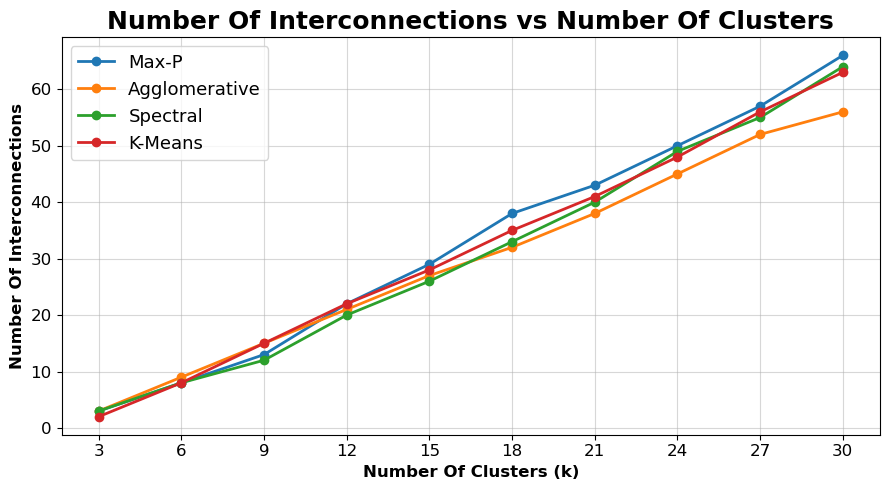

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ── Config ──
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

colours = {
    'MaxP_Rook': '#1f77b4',
    'Agglomerative': '#ff7f0e',
    'Spectral': '#2ca02c',
    'KMeans_Spatial': '#d62728'
}
labels = {
    'MaxP_Rook': 'Max-P',
    'Agglomerative': 'Agglomerative',
    'Spectral': 'Spectral',
    'KMeans_Spatial': 'K-Means'
}

# ── Load link counts from reduced_links.csv ──
link_counts = {m: [] for m in methods}

for method in methods:
    for k in ks:
        links_path = f"{base_dir}/{method}/{method}_k{k}/reduced_links.csv"
        if not os.path.exists(links_path):
            continue
        n_links = len(pd.read_csv(links_path))
        link_counts[method].append({'k': k, 'n_links': n_links})

# ── Plot ──
fig, ax = plt.subplots(figsize=(9, 5))

for method in methods:
    df_m = pd.DataFrame(link_counts[method]).sort_values('k')
    if df_m.empty:
        continue
    ax.plot(
        df_m['k'],
        df_m['n_links'],
        marker='o',
        markersize=6,
        color=colours[method],
        label=labels[method],
        linewidth=2
    )

ax.set_xlabel('Number Of Clusters (k)', fontweight='bold', fontsize=12)
ax.set_ylabel('Number Of Interconnections', fontweight='bold', fontsize=12)
ax.set_xticks(ks)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(True, alpha=0.5)
ax.set_title('Number Of Interconnections vs Number Of Clusters', fontsize=18, fontweight='bold')
ax.legend(fontsize=13)

plt.tight_layout()
plt.savefig('4YP_Figures/interconnections_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

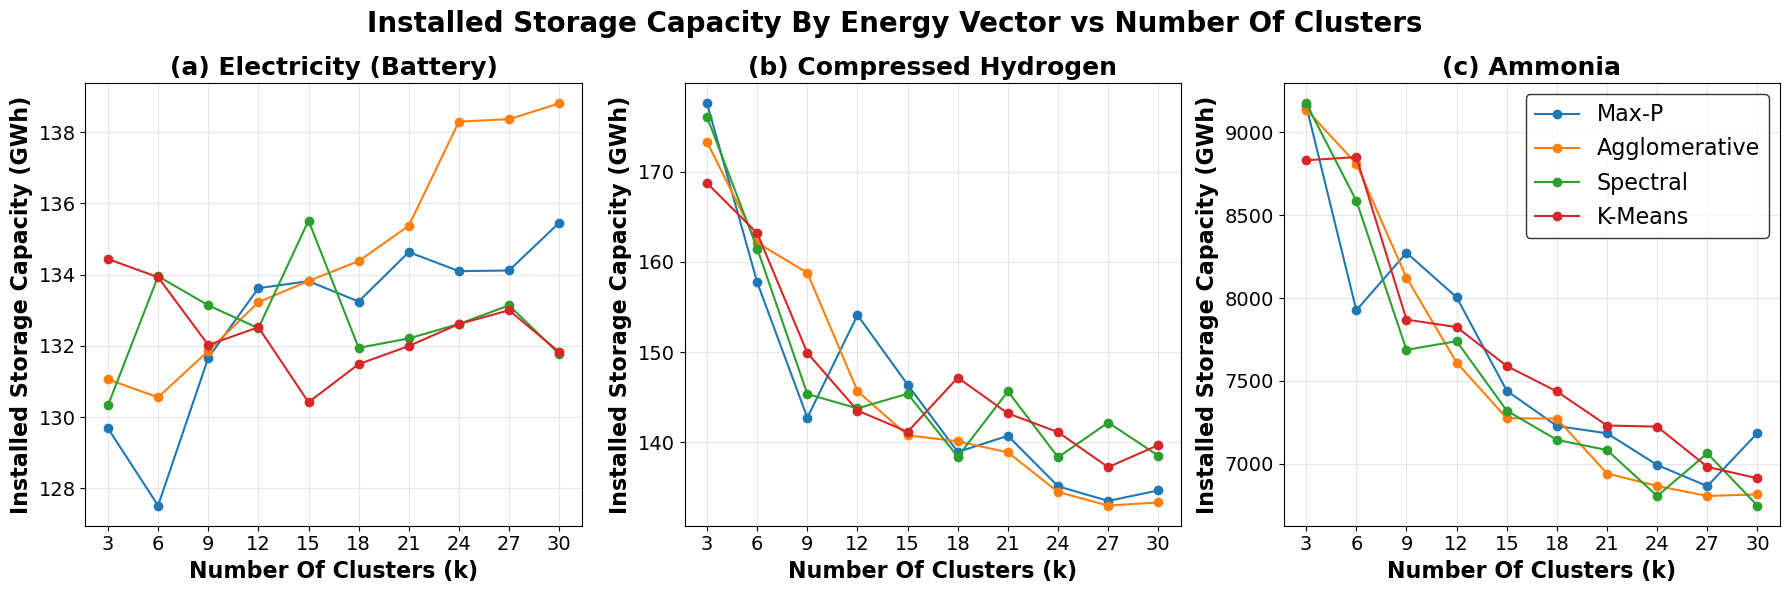

In [15]:
import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt

# ── Config ──
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

colours = {
    'MaxP_Rook': '#1f77b4',
    'Agglomerative': '#ff7f0e',
    'Spectral': '#2ca02c',
    'KMeans_Spatial': '#d62728'
}
labels = {
    'MaxP_Rook': 'Max-P',
    'Agglomerative': 'Agglomerative',
    'Spectral': 'Spectral',
    'KMeans_Spatial': 'K-Means'
}

# Storage tech groupings
storage_groups = {
    'battery_gwh': ['battery'],
    'hydrogen_gwh': ['compressed_hydrogen_storage', 'cavern_hydrogen_storage'],
    'ammonia_gwh': ['ammonia_storage']
}

# ── Load storage capacities ──
all_records = {m: [] for m in methods}

for method in methods:
    for k in ks:
        nc_path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(nc_path):
            print(f"Missing: {nc_path}")
            continue

        model = calliope.read_netcdf(nc_path)

        sc = model.results.storage_cap.to_dataframe().reset_index()
        sc.columns = ['loc_techs', 'storage_cap']
        sc['tech'] = sc['loc_techs'].str.split('::').str[-1]
        sc = sc[sc['storage_cap'].notna()]
        tech_totals = sc.groupby('tech')['storage_cap'].sum()

        row = {'k': k}
        row['battery_gwh'] = sum(tech_totals.get(t, 0.0) for t in storage_groups['battery_gwh']) / 1e3
        row['hydrogen_gwh'] = sum(tech_totals.get(t, 0.0) for t in storage_groups['hydrogen_gwh']) / 1e3
        row['ammonia_gwh'] = sum(tech_totals.get(t, 0.0) for t in storage_groups['ammonia_gwh']) / 1e3

        all_records[method].append(row)
        del model
        gc.collect()

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

subplot_config = [
    (axes[0], 'battery_gwh', '(a) Electricity (Battery)'),
    (axes[1], 'hydrogen_gwh', '(b) Compressed Hydrogen'),
    (axes[2], 'ammonia_gwh', '(c) Ammonia')
]

for ax, col, title in subplot_config:
    for method in methods:
        df_m = pd.DataFrame(all_records[method]).sort_values('k')
        if df_m.empty:
            continue

        ax.plot(
            df_m['k'],
            df_m[col],
            marker='o',
            markersize=6,
            color=colours[method],
            label=labels[method]
        )

    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xlabel('Number Of Clusters (k)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Installed Storage Capacity (GWh)', fontsize=16, fontweight='bold')
    ax.set_xticks(ks)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    
    if col == 'ammonia_gwh':
        leg_sub = ax.legend(fontsize=16, loc='upper right')
        leg_sub.get_frame().set_edgecolor('black')

fig.suptitle('Installed Storage Capacity By Energy Vector vs Number Of Clusters', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('4YP_Figures/storage_capacity_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

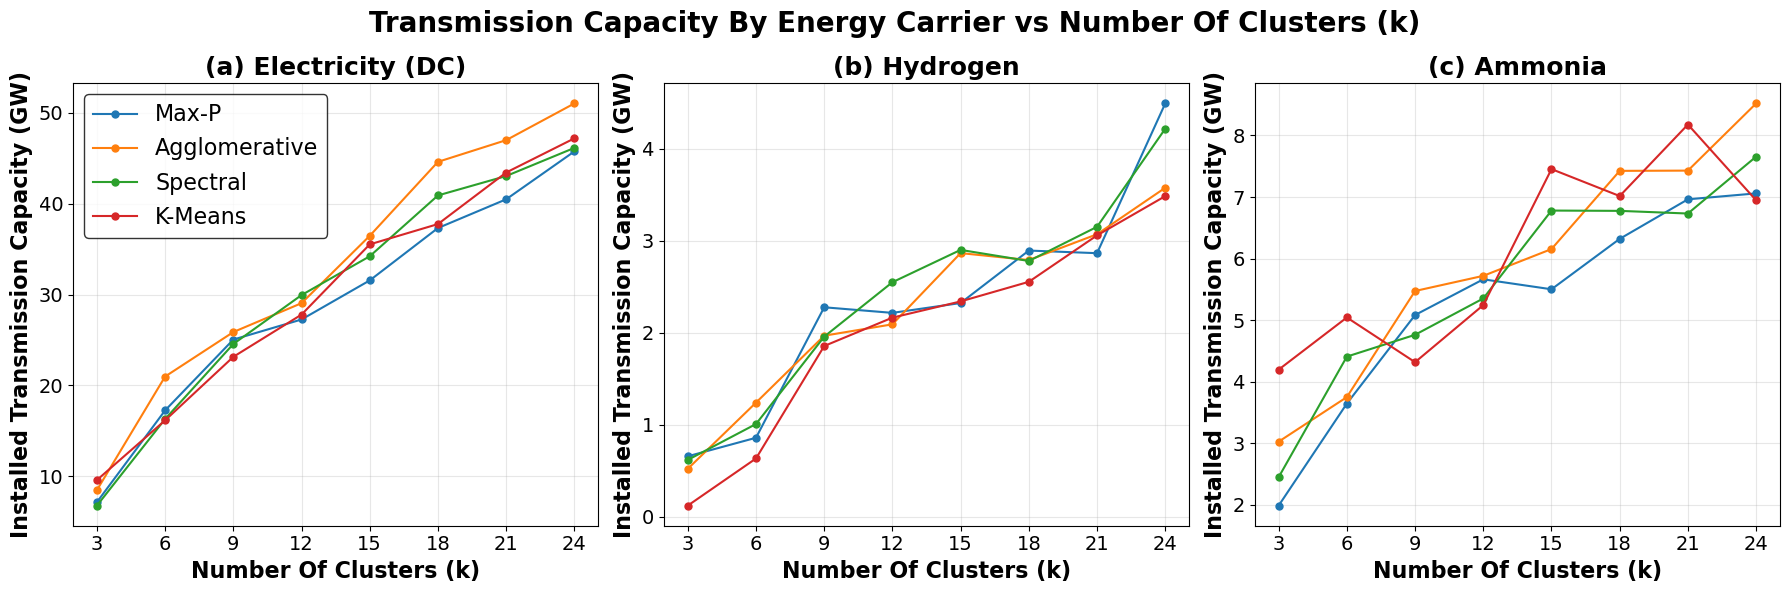

In [3]:
import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt

# ── Config ──
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24]

colours = {
    'MaxP_Rook': '#1f77b4',
    'Agglomerative': '#ff7f0e',
    'Spectral': '#2ca02c',
    'KMeans_Spatial': '#d62728'
}
labels = {
    'MaxP_Rook': 'Max-P',
    'Agglomerative': 'Agglomerative',
    'Spectral': 'Spectral',
    'KMeans_Spatial': 'K-Means'
}

# Transmission tech groupings
transmission_groups = {
    'dc_gw': ['dc_transmission'],
    'hydrogen_gw': ['hydrogen_pipeline'],
    'ammonia_gw': ['ammonia_pipeline']
}

# ── Load transmission capacities ──
all_records = {m: [] for m in methods}

for method in methods:
    for k in ks:
        nc_path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(nc_path):
            print(f"Missing: {nc_path}")
            continue

        model = calliope.read_netcdf(nc_path)

        ec = model.results.energy_cap.to_dataframe().reset_index()
        ec.columns = ['loc_techs', 'energy_cap']
        ec['tech'] = ec['loc_techs'].str.split('::').str[-1].str.split(':').str[0]
        ec = ec[ec['energy_cap'].notna()]
        tech_totals = ec.groupby('tech')['energy_cap'].sum()

        row = {'k': k}
        row['dc_gw'] = sum(tech_totals.get(t, 0.0) for t in transmission_groups['dc_gw']) / 2.0 / 1e3
        row['hydrogen_gw'] = sum(tech_totals.get(t, 0.0) for t in transmission_groups['hydrogen_gw']) / 2.0 / 1e3
        row['ammonia_gw'] = sum(tech_totals.get(t, 0.0) for t in transmission_groups['ammonia_gw']) / 2.0 / 1e3

        all_records[method].append(row)
        del model
        gc.collect()

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

subplot_config = [
    (axes[0], 'dc_gw', '(a) Electricity (DC)'),
    (axes[1], 'hydrogen_gw', '(b) Hydrogen'),
    (axes[2], 'ammonia_gw', '(c) Ammonia')
]

for ax, col, title in subplot_config:
    for method in methods:
        df_m = pd.DataFrame(all_records[method]).sort_values('k')
        if df_m.empty:
            continue

        ax.plot(
            df_m['k'],
            df_m[col],
            marker='o',
            markersize=5,
            color=colours[method],
            label=labels[method]
        )

    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xlabel('Number Of Clusters (k)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Installed Transmission Capacity (GW)', fontsize=16, fontweight='bold')
    ax.set_xticks(ks)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

    if col == 'dc_gw':
        leg_sub = ax.legend(fontsize=16, loc='upper left')
        leg_sub.get_frame().set_edgecolor('black')

fig.suptitle('Transmission Capacity By Energy Carrier vs Number Of Clusters (k)', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('4YP_Figures/transmission_capacity_by_carrier_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

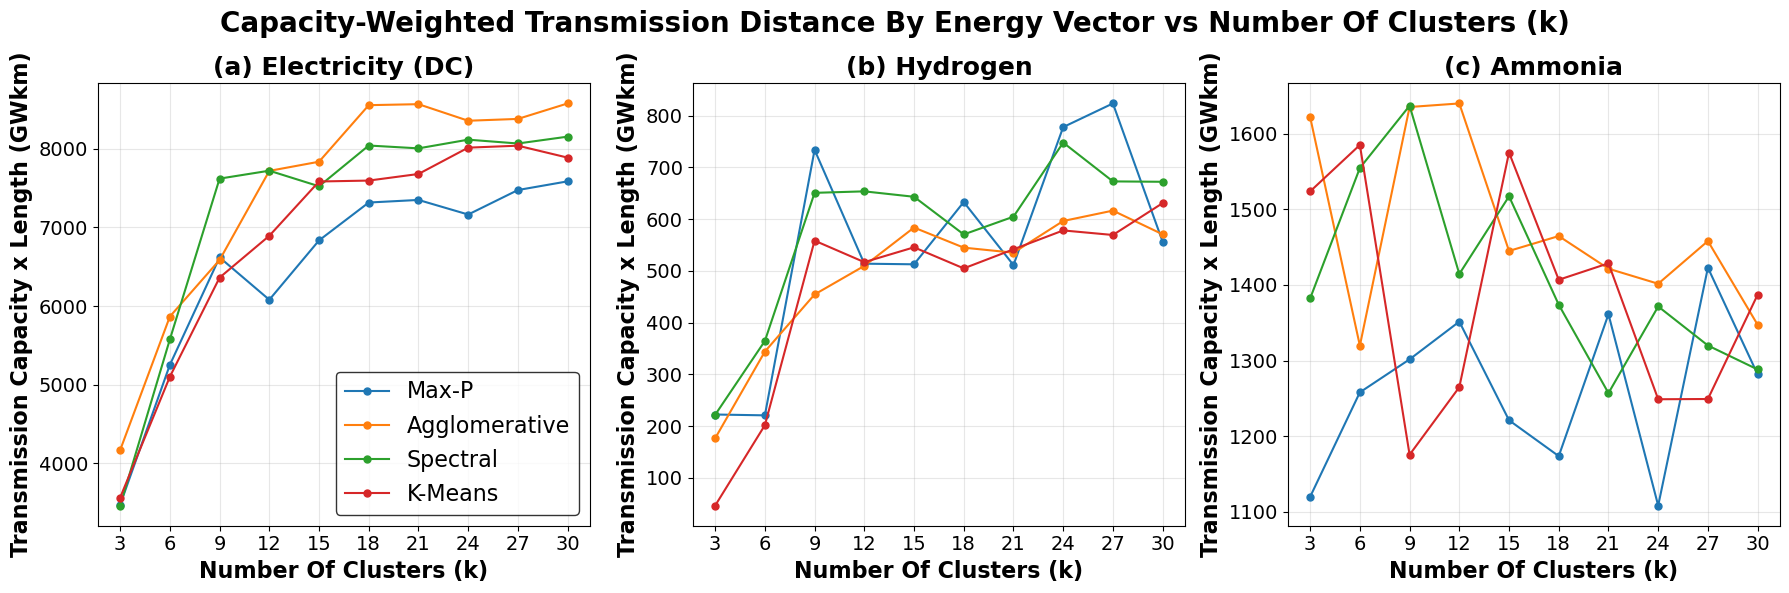

In [14]:
import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt

# ── Config ──
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

colours = {
    'MaxP_Rook': '#1f77b4',
    'Agglomerative': '#ff7f0e',
    'Spectral': '#2ca02c',
    'KMeans_Spatial': '#d62728'
}
labels = {
    'MaxP_Rook': 'Max-P',
    'Agglomerative': 'Agglomerative',
    'Spectral': 'Spectral',
    'KMeans_Spatial': 'K-Means'
}

def make_node_name(lat, lon):
    return f"region_{str(lat).replace('.', '_')}_{str(lon).replace('.', '_')}"

# ── Load transmission capacity × length ──
all_records = {m: [] for m in methods}

for method in methods:
    for k in ks:
        nc_path    = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        meta_path  = f"{base_dir}/{method}/{method}_k{k}/cluster_metadata.csv"
        links_path = f"{base_dir}/{method}/{method}_k{k}/reduced_links.csv"
        if not os.path.exists(nc_path):
            print(f"Missing: {nc_path}")
            continue

        # Build (cluster_a, cluster_b) → mean_distance_km lookup
        links = pd.read_csv(links_path)
        dist_lookup = {
            (int(r['cluster_a']), int(r['cluster_b'])): r['mean_distance_km']
            for _, r in links.iterrows()
        }

        # Build node_name → cluster_id lookup
        meta = pd.read_csv(meta_path)
        meta['node_name'] = meta.apply(lambda r: make_node_name(r['lat'], r['lon']), axis=1)
        name_to_cid = meta.set_index('node_name')['cluster_id'].to_dict()

        model = calliope.read_netcdf(nc_path)

        ec = model.results.energy_cap.to_dataframe().reset_index()
        ec.columns = ['loc_techs', 'energy_cap']
        ec = ec[ec['energy_cap'].notna()].copy()
        ec['loc_from']  = ec['loc_techs'].str.split('::').str[0]
        ec['tech_rest'] = ec['loc_techs'].str.split('::').str[1]
        ec['tech']      = ec['tech_rest'].str.split(':').str[0]
        ec['loc_to']    = ec['tech_rest'].apply(
            lambda s: s.split(':', 1)[1] if isinstance(s, str) and ':' in s else None
        )
        ec_trans = ec[ec['loc_to'].notna()][['loc_from', 'tech', 'loc_to', 'energy_cap']].copy()
        ec_trans['_key'] = ec_trans.apply(
            lambda r: tuple(sorted([r['loc_from'], r['loc_to']])) + (r['tech'],), axis=1
        )
        ec_trans = ec_trans.drop_duplicates(subset='_key').drop(columns='_key').reset_index(drop=True)
        ec_trans = ec_trans[ec_trans['energy_cap'] > 0].reset_index(drop=True)

        def gwkm_for_techs(tech_list):
            df = ec_trans[ec_trans['tech'].isin(tech_list)]
            total = 0.0
            for _, lnk in df.iterrows():
                cid_a = name_to_cid.get(lnk['loc_from'])
                cid_b = name_to_cid.get(lnk['loc_to'])
                if cid_a is None or cid_b is None:
                    continue
                key = (min(cid_a, cid_b), max(cid_a, cid_b))
                dist = dist_lookup.get(key, 0.0)
                total += (lnk['energy_cap'] / 1e3) * dist
            return total

        row = {'k': k}
        row['dc_gwkm']       = gwkm_for_techs(['dc_transmission'])
        row['hydrogen_gwkm'] = gwkm_for_techs(['hydrogen_pipeline'])
        row['ammonia_gwkm']  = gwkm_for_techs(['ammonia_pipeline'])

        all_records[method].append(row)
        del model
        gc.collect()

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

subplot_config = [
    (axes[0], 'dc_gwkm',       '(a) Electricity (DC)'),
    (axes[1], 'hydrogen_gwkm', '(b) Hydrogen'),
    (axes[2], 'ammonia_gwkm',  '(c) Ammonia')
]

for ax, col, title in subplot_config:
    for method in methods:
        df_m = pd.DataFrame(all_records[method]).sort_values('k')
        if df_m.empty:
            continue

        ax.plot(
            df_m['k'],
            df_m[col],
            marker='o',
            markersize=5,
            color=colours[method],
            label=labels[method]
        )

    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xlabel('Number Of Clusters (k)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Transmission Capacity x Length (GWkm)', fontsize=16, fontweight='bold')
    ax.set_xticks(ks)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

    if col == 'dc_gwkm':
        leg_sub = ax.legend(fontsize=16, loc='lower right')
        leg_sub.get_frame().set_edgecolor('black')

fig.suptitle('Capacity-Weighted Transmission Distance By Energy Vector vs Number Of Clusters (k)', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('4YP_Figures/transmission_capacity_x_distance_by_carrier_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

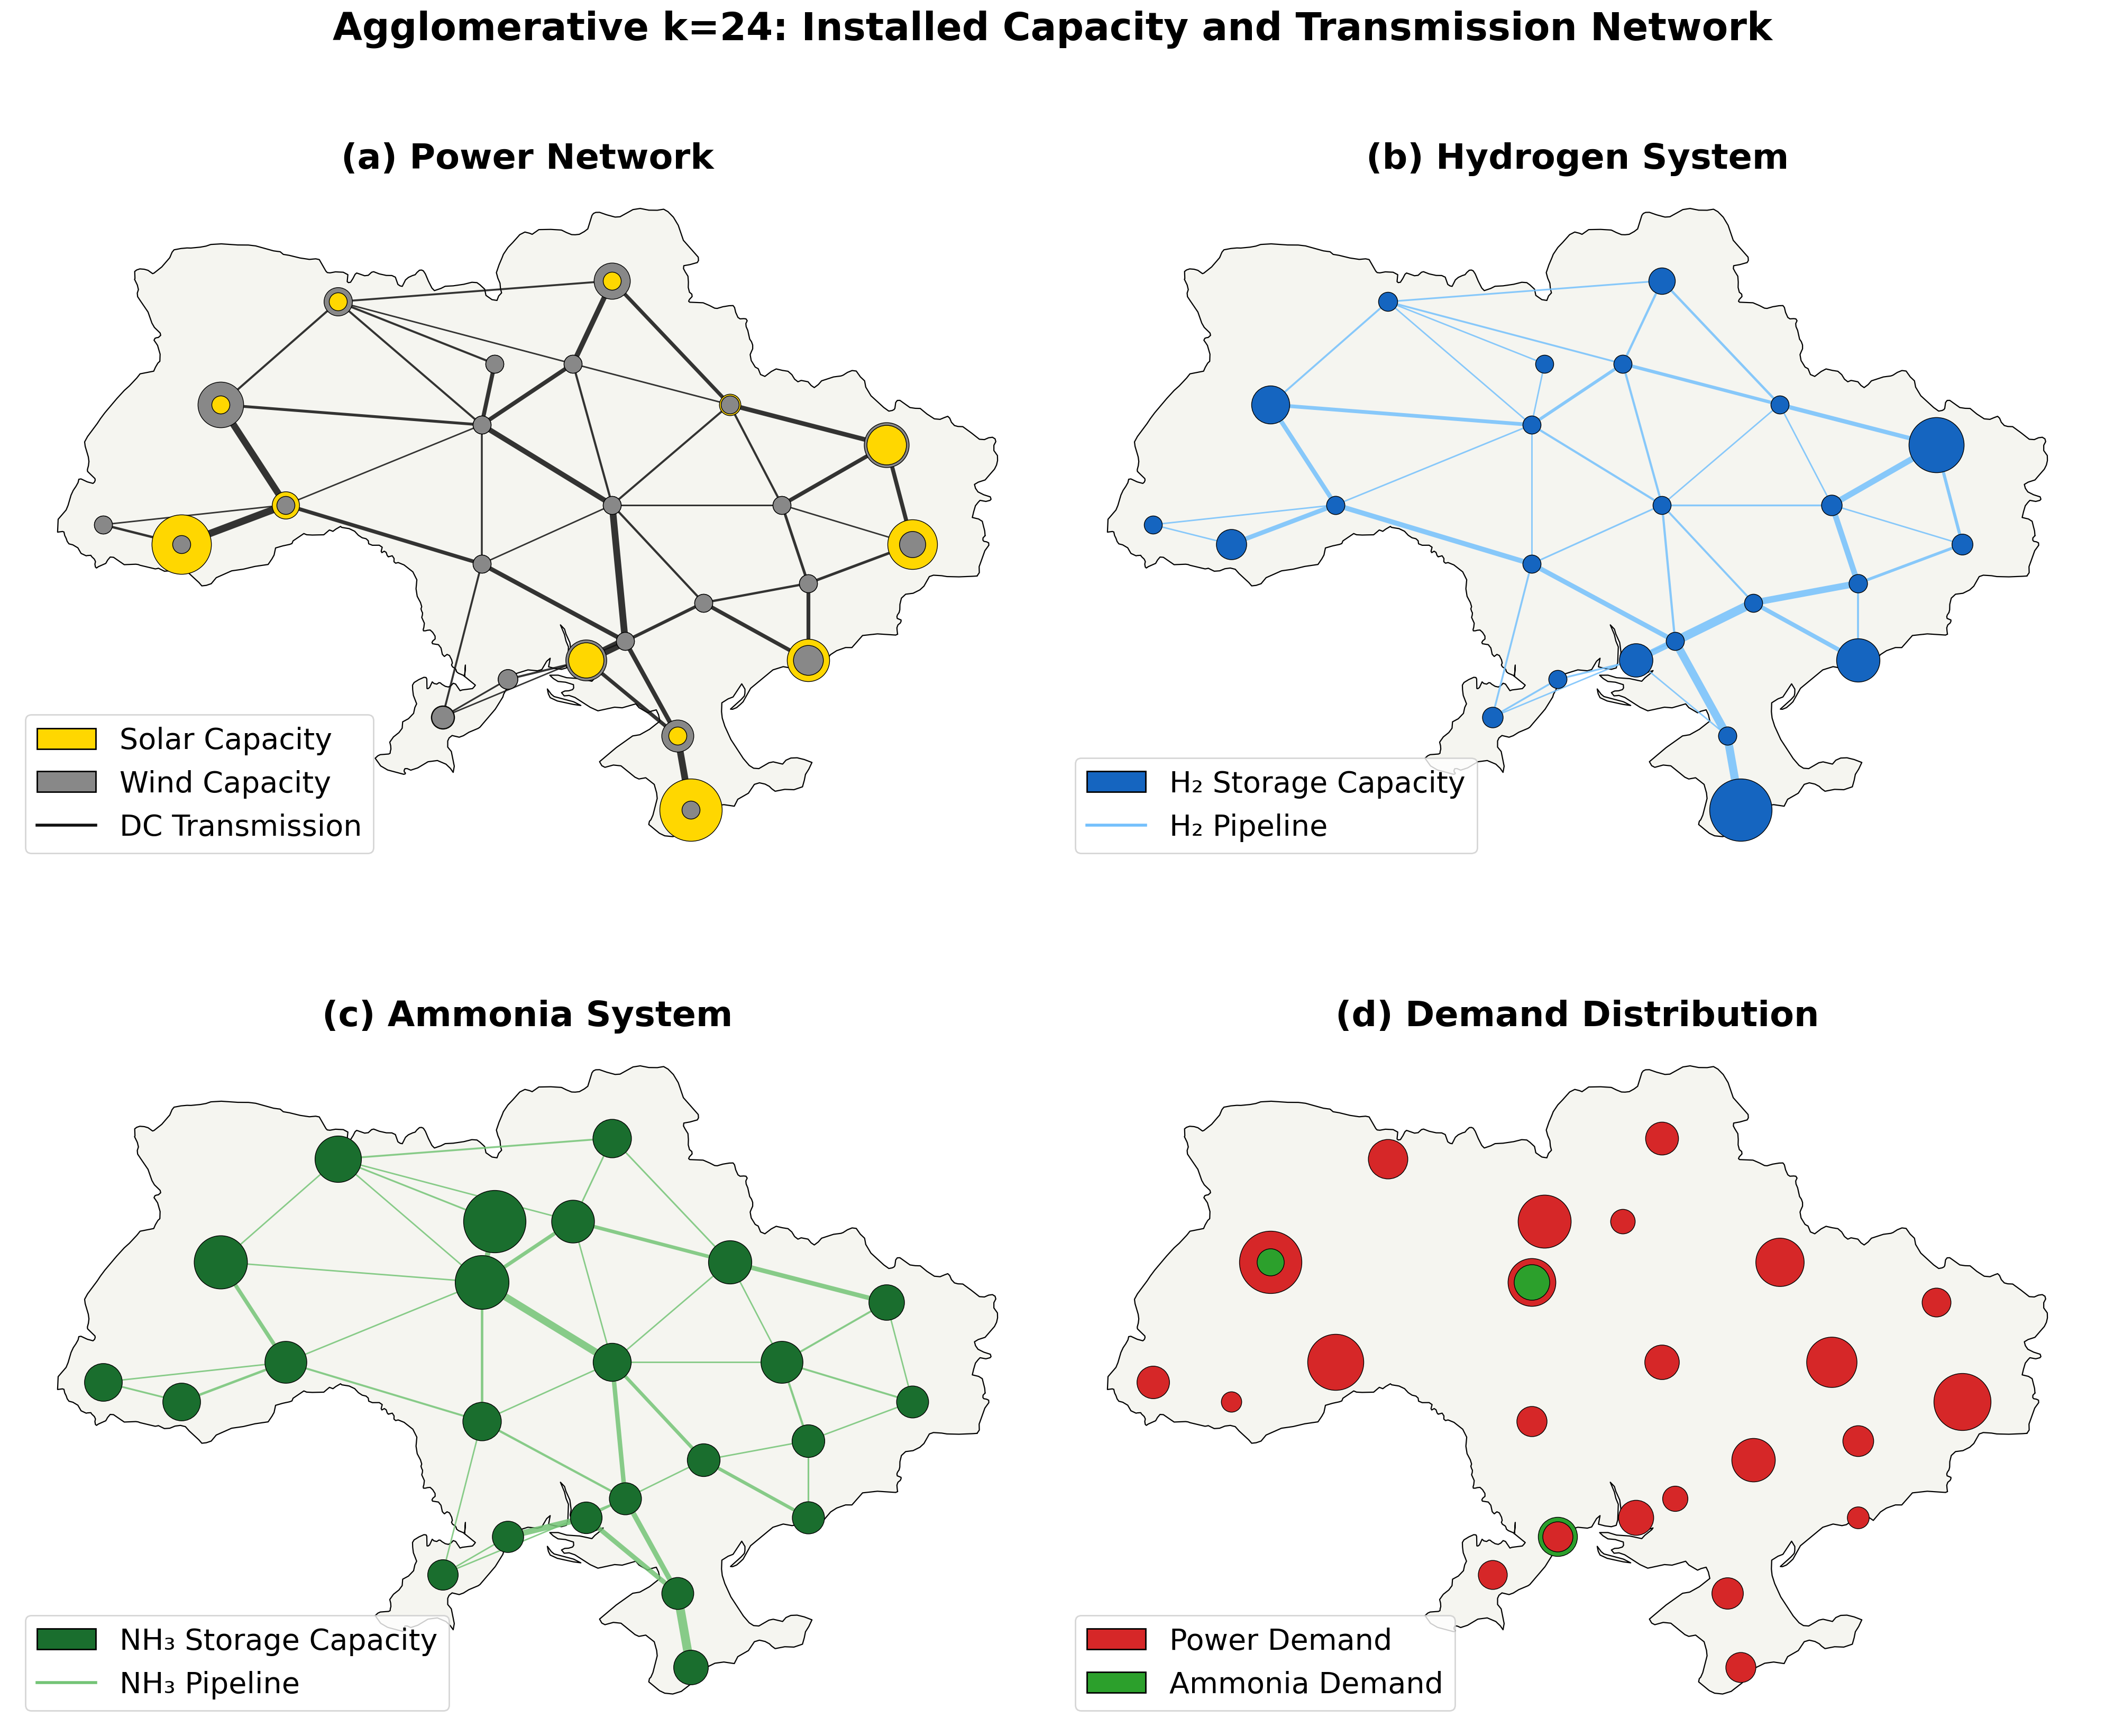

In [1]:
import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ── Paths ──
BASE = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/Agglomerative/Agglomerative_k24'
NC_PATH = f"{BASE}/weighted_percentile_timeseries/Agglomerative_weighted_k24_bidirectional.nc"
META_PATH = f"{BASE}/cluster_metadata.csv"
DEMAND_PATH = f"{BASE}/cluster_demand_profiles.csv"
BOUNDARY_PATH = 'data_prep/data/ukraine_merged_dissolved_noholes.geojson'
OUT_PATH = '4YP_Figures/agglomerative_k24_capacity_network.png'
CRS = 'EPSG:3857'
MIN_S, MAX_S = 150, 1800
MIN_LW, MAX_LW = 1, 6.0

# ── Scaling helpers ──
def scale_to_common(series, common_max):
    if common_max == 0:
        return pd.Series(0, index=series.index)
    scaled = MIN_S + (MAX_S - MIN_S) * series.clip(lower=0) / common_max
    return scaled.where(series > 0, 0).clip(upper=MAX_S)

def scale_lw(series):
    mx = series.max()
    if mx == 0:
        return pd.Series(MIN_LW, index=series.index)
    return MIN_LW + (MAX_LW - MIN_LW) * series / mx

# ── Load boundary ──
boundary = gpd.read_file(BOUNDARY_PATH).to_crs(CRS)

# ── Load metadata & build node positions ──
meta = pd.read_csv(META_PATH)

def make_node_name(lat, lon):
    return f"region_{str(lat).replace('.', '_')}_{str(lon).replace('.', '_')}"

meta['node_name'] = meta.apply(lambda r: make_node_name(r['lat'], r['lon']), axis=1)

node_gdf = gpd.GeoDataFrame(
    meta.copy(),
    geometry=gpd.points_from_xy(meta['lon'], meta['lat']),
    crs='EPSG:4326'
).to_crs(CRS)
node_gdf['x'] = node_gdf.geometry.x
node_gdf['y'] = node_gdf.geometry.y
node_pos = dict(zip(node_gdf['node_name'], zip(node_gdf['x'], node_gdf['y'])))

# ── Load demand profiles ──
demand_df = pd.read_csv(DEMAND_PATH, index_col=0)
mean_demand = demand_df.abs().mean()
mean_demand.index = [int(c.split('_')[1]) for c in mean_demand.index]

# ── Load .nc model results ──
model = calliope.read_netcdf(NC_PATH)

# Parse energy_cap
ec_raw = model.results.energy_cap.to_dataframe().reset_index()
ec_raw.columns = ['loc_techs', 'energy_cap']
ec_raw = ec_raw[ec_raw['energy_cap'].notna()].copy()
ec_raw['loc_from'] = ec_raw['loc_techs'].str.split('::').str[0]
ec_raw['tech_rest'] = ec_raw['loc_techs'].str.split('::').str[1]
ec_raw['tech'] = ec_raw['tech_rest'].str.split(':').str[0]
ec_raw['loc_to'] = ec_raw['tech_rest'].apply(
    lambda s: s.split(':', 1)[1] if isinstance(s, str) and ':' in s else None
)
ec_point = ec_raw[ec_raw['loc_to'].isna()][['loc_from', 'tech', 'energy_cap']].rename(
    columns={'loc_from': 'loc'}
).copy()
ec_trans = ec_raw[ec_raw['loc_to'].notna()][['loc_from', 'tech', 'loc_to', 'energy_cap']].copy()
ec_trans['_key'] = ec_trans.apply(
    lambda r: tuple(sorted([r['loc_from'], r['loc_to']])) + (r['tech'],), axis=1
)
ec_trans = ec_trans.drop_duplicates(subset='_key').drop(columns='_key').reset_index(drop=True)
ec_trans = ec_trans[ec_trans['energy_cap'] > 0].reset_index(drop=True)

# Parse storage_cap
sc_raw = model.results.storage_cap.to_dataframe().reset_index()
sc_raw.columns = ['loc_techs', 'storage_cap']
sc_raw = sc_raw[sc_raw['storage_cap'].notna()].copy()
sc_raw['loc'] = sc_raw['loc_techs'].str.split('::').str[0]
sc_raw['tech'] = sc_raw['loc_techs'].str.split('::').str[1]

del model
gc.collect()

# ── Plotting helpers ──
def draw_links(ax, tech_name, color):
    df = ec_trans[ec_trans['tech'] == tech_name].copy()
    if df.empty:
        return
    lws = scale_lw(df['energy_cap']).values
    for (_, row), lw in zip(df.iterrows(), lws):
        p1 = node_pos.get(row['loc_from'])
        p2 = node_pos.get(row['loc_to'])
        if p1 and p2:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=lw, zorder=2, alpha=0.85)

def get_point_caps(tech_list):
    return ec_point[ec_point['tech'].isin(tech_list)].groupby('loc')['energy_cap'].sum()

def get_storage_caps(tech_list):
    return sc_raw[sc_raw['tech'].isin(tech_list)].groupby('loc')['storage_cap'].sum()

def draw_two_markers(ax, caps_a, caps_b, col_a, col_b, common_max):
    for node_name, (x, y) in node_pos.items():
        val_a = caps_a.get(node_name, 0)
        val_b = caps_b.get(node_name, 0)
        s_a = scale_to_common(pd.Series([val_a]), common_max).iloc[0]
        s_b = scale_to_common(pd.Series([val_b]), common_max).iloc[0]
        if s_a >= s_b:
            if s_a > 0: ax.scatter(x, y, s=s_a, color=col_a, edgecolors='k', linewidths=0.5, zorder=3)
            if s_b > 0: ax.scatter(x, y, s=s_b, color=col_b, edgecolors='k', linewidths=0.5, zorder=4)
        else:
            if s_b > 0: ax.scatter(x, y, s=s_b, color=col_b, edgecolors='k', linewidths=0.5, zorder=3)
            if s_a > 0: ax.scatter(x, y, s=s_a, color=col_a, edgecolors='k', linewidths=0.5, zorder=4)

def draw_single_markers(ax, caps, color, common_max, zorder=3):
    for node_name, (x, y) in node_pos.items():
        val = caps.get(node_name, 0)
        s = scale_to_common(pd.Series([val]), common_max).iloc[0]
        if s > 0:
            ax.scatter(x, y, s=s, color=color, edgecolors='k', linewidths=0.5, zorder=zorder)

# ── Figure ──
fig, axes = plt.subplots(2, 2, figsize=(20, 18), dpi=200)
fig.suptitle('Agglomerative k=24: Installed Capacity and Transmission Network',
             fontsize=26, fontweight='bold', y=0.98)

# ── (a) Power network ──
ax = axes[0, 0]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
draw_links(ax, 'dc_transmission', '#111111')
solar_caps = get_point_caps(['solar_single_axis'])
wind_caps = get_point_caps(['onshore_wind'])
common_max_a = max(solar_caps.max() if not solar_caps.empty else 0,
                   wind_caps.max() if not wind_caps.empty else 0)
draw_two_markers(ax, solar_caps, wind_caps, '#FFD700', '#888888', common_max_a)
ax.set_title('(a) Power Network', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#FFD700', edgecolor='k', label='Solar Capacity'),
    Patch(facecolor='#888888', edgecolor='k', label='Wind Capacity'),
    Line2D([0], [0], color='#111111', linewidth=2, label='DC Transmission'),
], fontsize=20, loc='lower left')

# ── (b) Hydrogen System ──
ax = axes[0, 1]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
draw_links(ax, 'hydrogen_pipeline', '#74c0fc')
h2_caps = get_storage_caps(['compressed_hydrogen_storage', 'cavern_hydrogen_storage'])
common_max_b = h2_caps.max() if not h2_caps.empty else 1
draw_single_markers(ax, h2_caps, '#1565C0', common_max_b)
ax.set_title('(b) Hydrogen System', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#1565C0', edgecolor='k', label='H₂ Storage Capacity'),
    Line2D([0], [0], color='#74c0fc', linewidth=2, label='H₂ Pipeline'),
], fontsize=20, loc='lower left')

# ── (c) Ammonia System ──
ax = axes[1, 0]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
draw_links(ax, 'ammonia_pipeline', '#74c476')
nh3_caps = get_storage_caps(['ammonia_storage'])
common_max_c = nh3_caps.max() if not nh3_caps.empty else 1
draw_single_markers(ax, nh3_caps, '#1a6e2e', common_max_c)
ax.set_title('(c) Ammonia System', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#1a6e2e', edgecolor='k', label='NH₃ Storage Capacity'),
    Line2D([0], [0], color='#74c476', linewidth=2, label='NH₃ Pipeline'),
], fontsize=20, loc='lower left')

# ── (d) Demand Distribution ──
ax = axes[1, 1]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
ammonia_demand_meta = meta.set_index('cluster_id')['ammonia_demand_MWh_hourly']
dem_max = max(mean_demand.max(), ammonia_demand_meta.max())
for _, row in node_gdf.iterrows():
    cid = row['cluster_id']
    x, y = row['x'], row['y']
    pd_val = mean_demand.get(cid, 0)
    am_val = ammonia_demand_meta.get(cid, 0)
    s_pow = scale_to_common(pd.Series([pd_val]), dem_max).iloc[0]
    s_amm = scale_to_common(pd.Series([am_val]), dem_max).iloc[0] if am_val > 0 else 0
    if s_pow >= s_amm:
        ax.scatter(x, y, s=s_pow, color='#d62728', edgecolors='k', linewidths=0.5, zorder=3)
        if am_val > 0:
            ax.scatter(x, y, s=s_amm, color='#2ca02c', edgecolors='k', linewidths=0.5, zorder=4)
    else:
        if am_val > 0:
            ax.scatter(x, y, s=s_amm, color='#2ca02c', edgecolors='k', linewidths=0.5, zorder=3)
        ax.scatter(x, y, s=s_pow, color='#d62728', edgecolors='k', linewidths=0.5, zorder=4)
ax.set_title('(d) Demand Distribution', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#d62728', edgecolor='k', label='Power Demand'),
    Patch(facecolor='#2ca02c', edgecolor='k', label='Ammonia Demand'),
], fontsize=20, loc='lower left')

plt.tight_layout(h_pad=2)
plt.savefig(OUT_PATH, dpi=200, bbox_inches='tight')
plt.show()

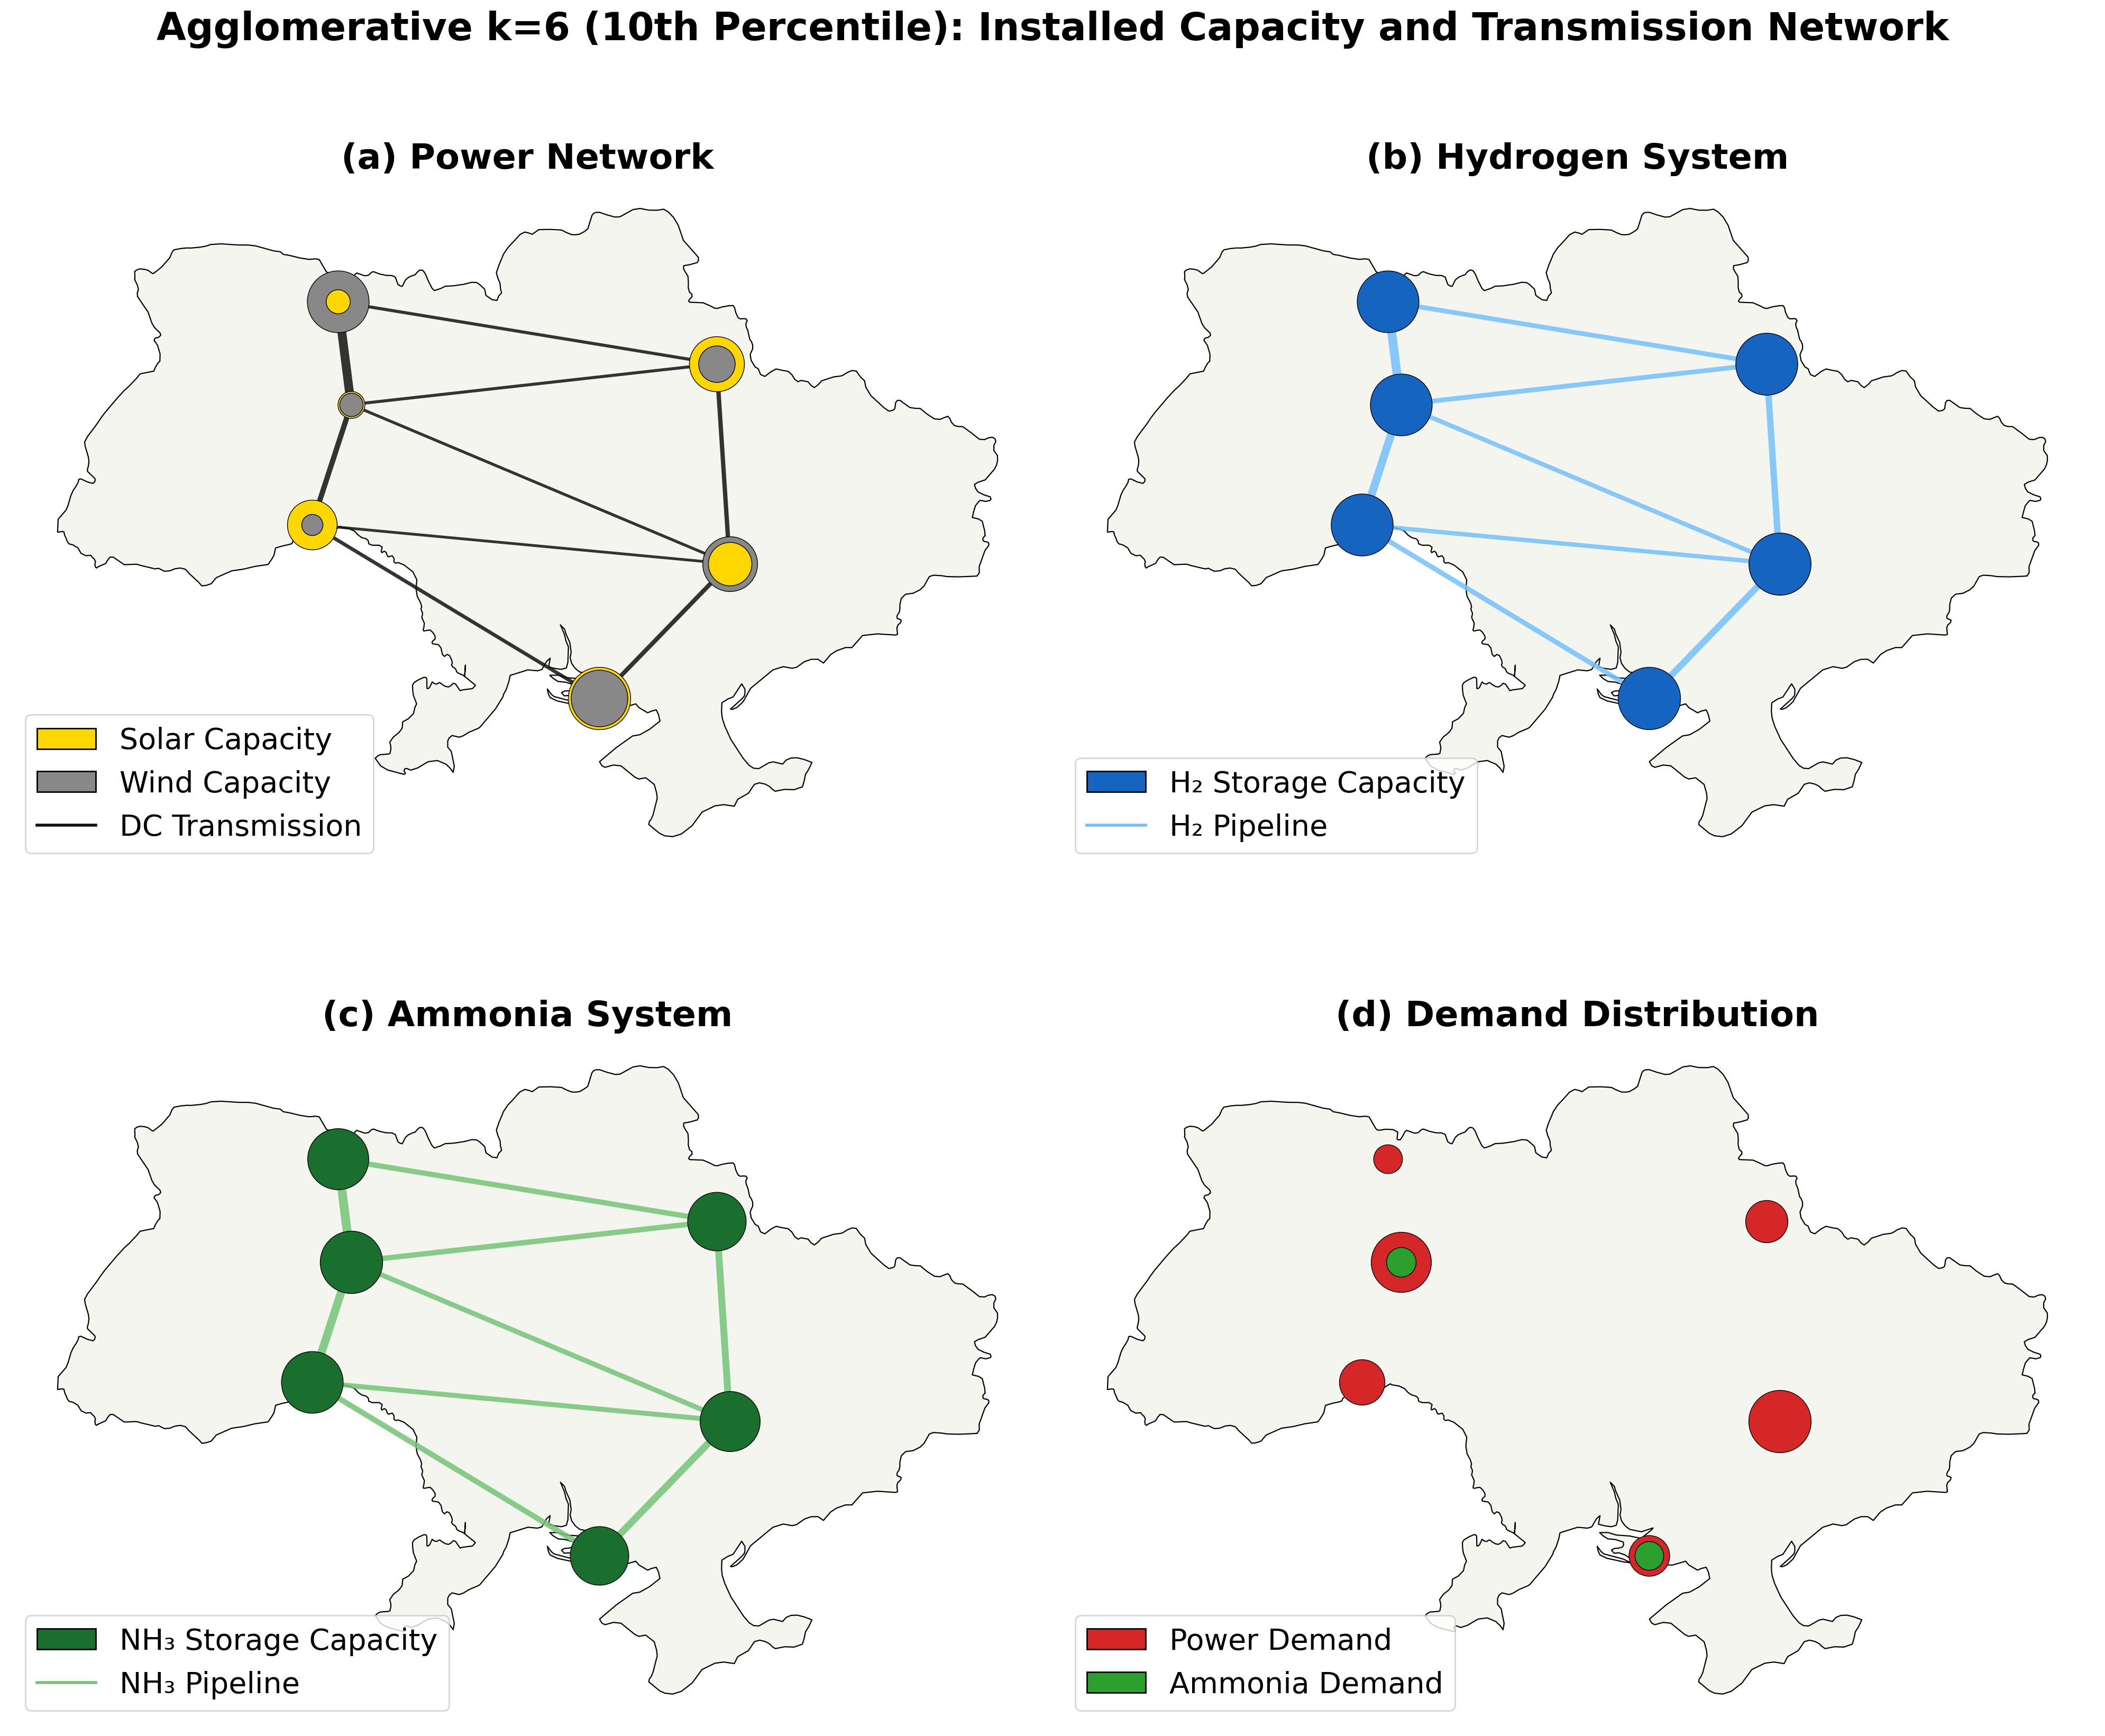

In [1]:
# 10th Percentile Agglomerative k = 6

import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ── Paths ──
BASE = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/Agglomerative/Agglomerative_k6'
NC_PATH = f"{BASE}/10_percentile_timeseries/Agglomerative_k6_10th_bidirectional.nc"
META_PATH = f"{BASE}/cluster_metadata.csv"
DEMAND_PATH = f"{BASE}/cluster_demand_profiles.csv"
BOUNDARY_PATH = 'data_prep/data/ukraine_merged_dissolved_noholes.geojson'
OUT_PATH = '4YP_Figures/agglomerative_k6_10th_capacity_network.png'
CRS = 'EPSG:3857'
MIN_S, MAX_S = 150, 1800
MIN_LW, MAX_LW = 1, 6.0

# ── Scaling helpers ──
def scale_to_common(series, common_max):
    if common_max == 0:
        return pd.Series(0, index=series.index)
    scaled = MIN_S + (MAX_S - MIN_S) * series.clip(lower=0) / common_max
    return scaled.where(series > 0, 0).clip(upper=MAX_S)

def scale_lw(series):
    mx = series.max()
    if mx == 0:
        return pd.Series(MIN_LW, index=series.index)
    return MIN_LW + (MAX_LW - MIN_LW) * series / mx

# ── Load boundary ──
boundary = gpd.read_file(BOUNDARY_PATH).to_crs(CRS)

# ── Load metadata & build node positions ──
meta = pd.read_csv(META_PATH)

def make_node_name(lat, lon):
    return f"region_{str(lat).replace('.', '_')}_{str(lon).replace('.', '_')}"

meta['node_name'] = meta.apply(lambda r: make_node_name(r['lat'], r['lon']), axis=1)

node_gdf = gpd.GeoDataFrame(
    meta.copy(),
    geometry=gpd.points_from_xy(meta['lon'], meta['lat']),
    crs='EPSG:4326'
).to_crs(CRS)
node_gdf['x'] = node_gdf.geometry.x
node_gdf['y'] = node_gdf.geometry.y
node_pos = dict(zip(node_gdf['node_name'], zip(node_gdf['x'], node_gdf['y'])))

# ── Load demand profiles ──
demand_df = pd.read_csv(DEMAND_PATH, index_col=0)
mean_demand = demand_df.abs().mean()
mean_demand.index = [int(c.split('_')[1]) for c in mean_demand.index]

# ── Load .nc model results ──
model = calliope.read_netcdf(NC_PATH)

# Parse energy_cap
ec_raw = model.results.energy_cap.to_dataframe().reset_index()
ec_raw.columns = ['loc_techs', 'energy_cap']
ec_raw = ec_raw[ec_raw['energy_cap'].notna()].copy()
ec_raw['loc_from'] = ec_raw['loc_techs'].str.split('::').str[0]
ec_raw['tech_rest'] = ec_raw['loc_techs'].str.split('::').str[1]
ec_raw['tech'] = ec_raw['tech_rest'].str.split(':').str[0]
ec_raw['loc_to'] = ec_raw['tech_rest'].apply(
    lambda s: s.split(':', 1)[1] if isinstance(s, str) and ':' in s else None
)
ec_point = ec_raw[ec_raw['loc_to'].isna()][['loc_from', 'tech', 'energy_cap']].rename(
    columns={'loc_from': 'loc'}
).copy()
ec_trans = ec_raw[ec_raw['loc_to'].notna()][['loc_from', 'tech', 'loc_to', 'energy_cap']].copy()
ec_trans['_key'] = ec_trans.apply(
    lambda r: tuple(sorted([r['loc_from'], r['loc_to']])) + (r['tech'],), axis=1
)
ec_trans = ec_trans.drop_duplicates(subset='_key').drop(columns='_key').reset_index(drop=True)
ec_trans = ec_trans[ec_trans['energy_cap'] > 0].reset_index(drop=True)

# Parse storage_cap
sc_raw = model.results.storage_cap.to_dataframe().reset_index()
sc_raw.columns = ['loc_techs', 'storage_cap']
sc_raw = sc_raw[sc_raw['storage_cap'].notna()].copy()
sc_raw['loc'] = sc_raw['loc_techs'].str.split('::').str[0]
sc_raw['tech'] = sc_raw['loc_techs'].str.split('::').str[1]

del model
gc.collect()

# ── Plotting helpers ──
def draw_links(ax, tech_name, color):
    df = ec_trans[ec_trans['tech'] == tech_name].copy()
    if df.empty:
        return
    lws = scale_lw(df['energy_cap']).values
    for (_, row), lw in zip(df.iterrows(), lws):
        p1 = node_pos.get(row['loc_from'])
        p2 = node_pos.get(row['loc_to'])
        if p1 and p2:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=lw, zorder=2, alpha=0.85)

def get_point_caps(tech_list):
    return ec_point[ec_point['tech'].isin(tech_list)].groupby('loc')['energy_cap'].sum()

def get_storage_caps(tech_list):
    return sc_raw[sc_raw['tech'].isin(tech_list)].groupby('loc')['storage_cap'].sum()

def draw_two_markers(ax, caps_a, caps_b, col_a, col_b, common_max):
    for node_name, (x, y) in node_pos.items():
        val_a = caps_a.get(node_name, 0)
        val_b = caps_b.get(node_name, 0)
        s_a = scale_to_common(pd.Series([val_a]), common_max).iloc[0]
        s_b = scale_to_common(pd.Series([val_b]), common_max).iloc[0]
        if s_a >= s_b:
            if s_a > 0: ax.scatter(x, y, s=s_a, color=col_a, edgecolors='k', linewidths=0.5, zorder=3)
            if s_b > 0: ax.scatter(x, y, s=s_b, color=col_b, edgecolors='k', linewidths=0.5, zorder=4)
        else:
            if s_b > 0: ax.scatter(x, y, s=s_b, color=col_b, edgecolors='k', linewidths=0.5, zorder=3)
            if s_a > 0: ax.scatter(x, y, s=s_a, color=col_a, edgecolors='k', linewidths=0.5, zorder=4)

def draw_single_markers(ax, caps, color, common_max, zorder=3):
    for node_name, (x, y) in node_pos.items():
        val = caps.get(node_name, 0)
        s = scale_to_common(pd.Series([val]), common_max).iloc[0]
        if s > 0:
            ax.scatter(x, y, s=s, color=color, edgecolors='k', linewidths=0.5, zorder=zorder)

# ── Figure ──
fig, axes = plt.subplots(2, 2, figsize=(20, 18), dpi=200)
fig.suptitle('Agglomerative k=6 (10th Percentile): Installed Capacity and Transmission Network',
             fontsize=26, fontweight='bold', y=0.98)

# ── (a) Power network ──
ax = axes[0, 0]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
draw_links(ax, 'dc_transmission', '#111111')
solar_caps = get_point_caps(['solar_single_axis'])
wind_caps = get_point_caps(['onshore_wind'])
common_max_a = max(solar_caps.max() if not solar_caps.empty else 0,
                   wind_caps.max() if not wind_caps.empty else 0)
draw_two_markers(ax, solar_caps, wind_caps, '#FFD700', '#888888', common_max_a)
ax.set_title('(a) Power Network', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#FFD700', edgecolor='k', label='Solar Capacity'),
    Patch(facecolor='#888888', edgecolor='k', label='Wind Capacity'),
    Line2D([0], [0], color='#111111', linewidth=2, label='DC Transmission'),
], fontsize=20, loc='lower left')

# ── (b) Hydrogen System ──
ax = axes[0, 1]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
draw_links(ax, 'hydrogen_pipeline', '#74c0fc')
h2_caps = get_storage_caps(['compressed_hydrogen_storage', 'cavern_hydrogen_storage'])
common_max_b = h2_caps.max() if not h2_caps.empty else 1
draw_single_markers(ax, h2_caps, '#1565C0', common_max_b)
ax.set_title('(b) Hydrogen System', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#1565C0', edgecolor='k', label='H₂ Storage Capacity'),
    Line2D([0], [0], color='#74c0fc', linewidth=2, label='H₂ Pipeline'),
], fontsize=20, loc='lower left')

# ── (c) Ammonia System ──
ax = axes[1, 0]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
draw_links(ax, 'ammonia_pipeline', '#74c476')
nh3_caps = get_storage_caps(['ammonia_storage'])
common_max_c = nh3_caps.max() if not nh3_caps.empty else 1
draw_single_markers(ax, nh3_caps, '#1a6e2e', common_max_c)
ax.set_title('(c) Ammonia System', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#1a6e2e', edgecolor='k', label='NH₃ Storage Capacity'),
    Line2D([0], [0], color='#74c476', linewidth=2, label='NH₃ Pipeline'),
], fontsize=20, loc='lower left')

# ── (d) Demand Distribution ──
ax = axes[1, 1]
boundary.plot(ax=ax, facecolor='#f5f5f0', edgecolor='black', linewidth=0.8, zorder=1)
ammonia_demand_meta = meta.set_index('cluster_id')['ammonia_demand_MWh_hourly']
dem_max = max(mean_demand.max(), ammonia_demand_meta.max())
for _, row in node_gdf.iterrows():
    cid = row['cluster_id']
    x, y = row['x'], row['y']
    pd_val = mean_demand.get(cid, 0)
    am_val = ammonia_demand_meta.get(cid, 0)
    s_pow = scale_to_common(pd.Series([pd_val]), dem_max).iloc[0]
    s_amm = scale_to_common(pd.Series([am_val]), dem_max).iloc[0] if am_val > 0 else 0
    if s_pow >= s_amm:
        ax.scatter(x, y, s=s_pow, color='#d62728', edgecolors='k', linewidths=0.5, zorder=3)
        if am_val > 0:
            ax.scatter(x, y, s=s_amm, color='#2ca02c', edgecolors='k', linewidths=0.5, zorder=4)
    else:
        if am_val > 0:
            ax.scatter(x, y, s=s_amm, color='#2ca02c', edgecolors='k', linewidths=0.5, zorder=3)
        ax.scatter(x, y, s=s_pow, color='#d62728', edgecolors='k', linewidths=0.5, zorder=4)
ax.set_title('(d) Demand Distribution', fontsize=24, fontweight='bold')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#d62728', edgecolor='k', label='Power Demand'),
    Patch(facecolor='#2ca02c', edgecolor='k', label='Ammonia Demand'),
], fontsize=20, loc='lower left')

plt.tight_layout(h_pad=2)
plt.savefig(OUT_PATH, dpi=200, bbox_inches='tight')
plt.show()

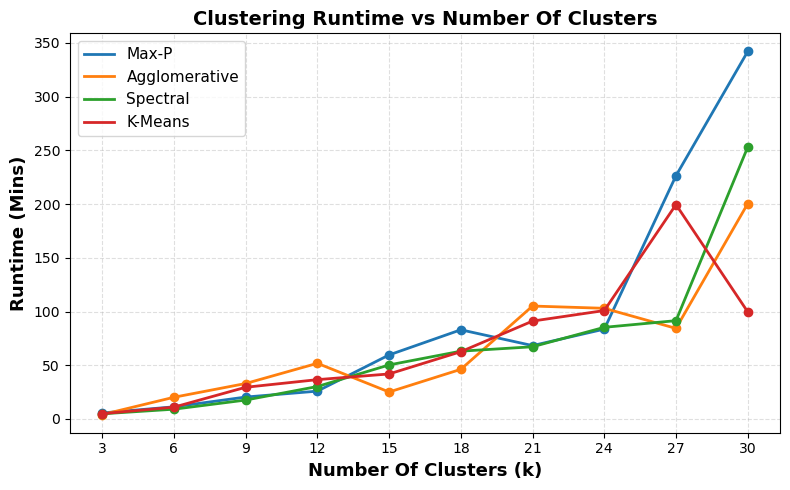

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CLUST_DIR = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
runtime = pd.read_csv(f'{CLUST_DIR}/cluster_runtime.csv', index_col=0)
runtime.columns = [int(c) for c in runtime.columns]

colours = {
    'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e',
    'Spectral': '#2ca02c',  'Kmeans_Spatial': '#d62728',
}
labels = {
    'MaxP_Rook': 'Max-P', 'Agglomerative': 'Agglomerative',
    'Spectral': 'Spectral',    'Kmeans_Spatial': 'K-Means',
}

fig, ax = plt.subplots(figsize=(8, 5))

for method in colours:
    ks   = list(runtime.columns)
    vals = runtime.loc[method].values
    ax.plot(ks, vals, marker='o', linewidth=2, markersize=6,
            color=colours[method], label=labels[method])

ax.set_xticks(ks)
ax.set_xlabel('Number Of Clusters (k)', fontsize=13, fontweight='bold')
ax.set_ylabel('Runtime (Mins)', fontsize=13, fontweight='bold')
ax.set_title('Clustering Runtime vs Number Of Clusters', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)

legend_handles = [
    Line2D([0], [0], color=colours[m], linewidth=2, label=labels[m])
    for m in colours
]
ax.legend(handles=legend_handles, fontsize=11)

plt.tight_layout()
plt.savefig('4YP_Figures/clustering_runtime_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

C:\Users\Benhd\AppData\Local\Temp\ipykernel_24676\4000877937.py:87: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



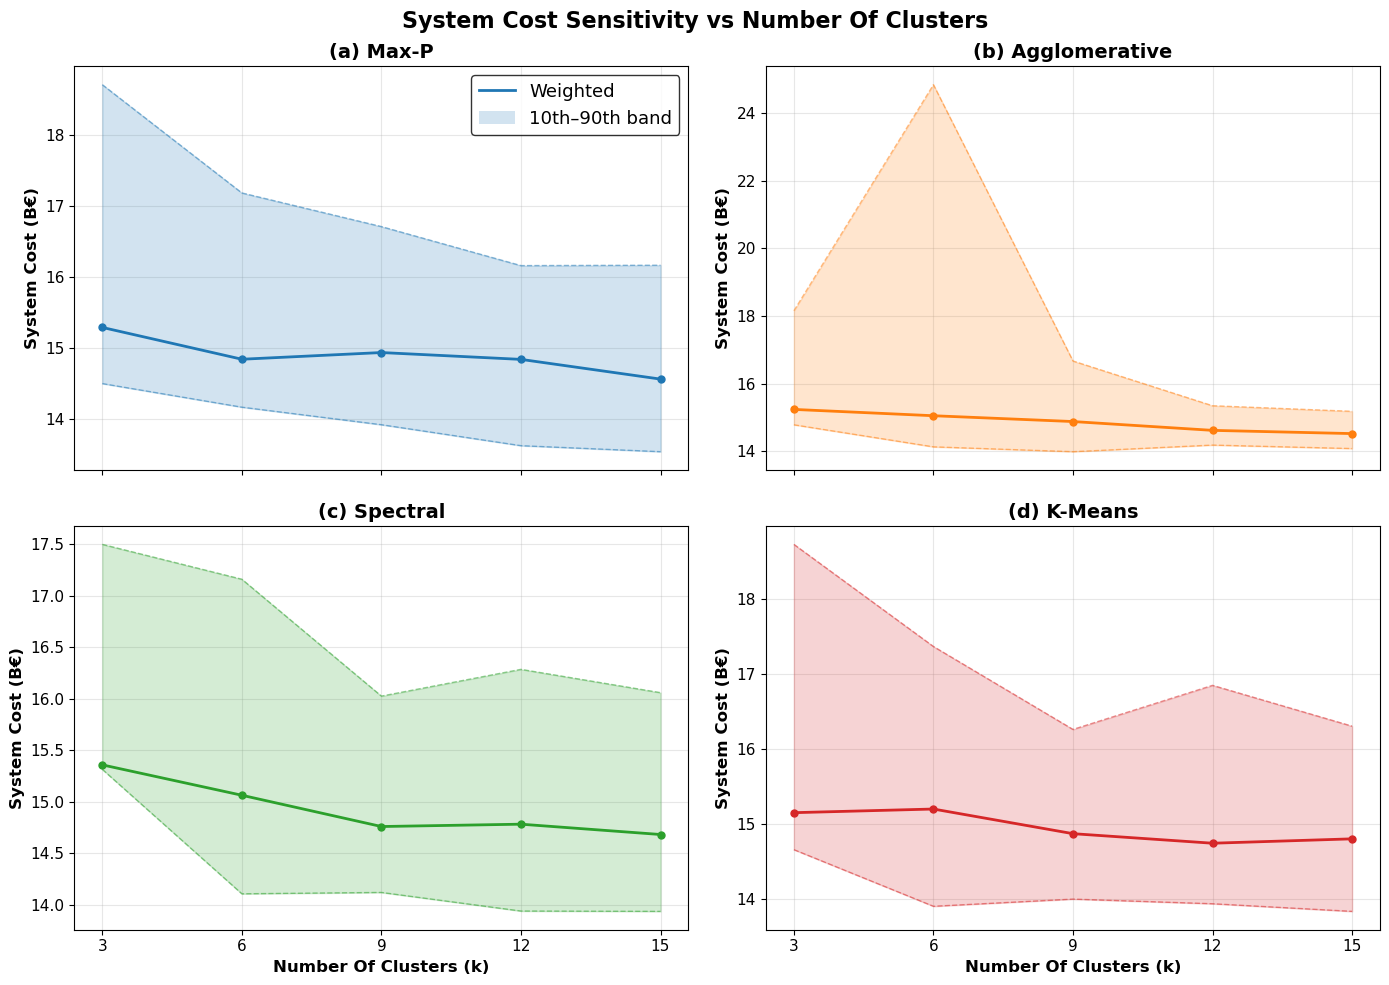

In [2]:
import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── Config ──
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods  = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks_main  = [3, 6, 9, 12, 15]
ks_sens  = [3, 6, 9, 12, 15]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means'}

# ── Load costs ──
weighted_costs = {m: {} for m in methods}
costs_10th     = {m: {} for m in methods}
costs_90th     = {m: {} for m in methods}

for method in methods:
    for k in ks_main:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(path):
            continue
        model = calliope.read_netcdf(path)
        weighted_costs[method][k] = float(model.results.cost.sum()) / 1e6  # B€
        del model; gc.collect()

    for k in ks_sens:
        path_10 = f"{base_dir}/{method}/{method}_k{k}/10_percentile_timeseries/{method}_k{k}_10th_bidirectional.nc"
        path_90 = f"{base_dir}/{method}/{method}_k{k}/90_percentile_timeseries/{method}_k{k}_90th_bidirectional.nc"
        if os.path.exists(path_10):
            model = calliope.read_netcdf(path_10)
            costs_10th[method][k] = float(model.results.cost.sum()) / 1e6
            del model; gc.collect()
        if os.path.exists(path_90):
            model = calliope.read_netcdf(path_90)
            costs_90th[method][k] = float(model.results.cost.sum()) / 1e6
            del model; gc.collect()

# ── Figure ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

panel_config = [
    (axes[0, 0], 'MaxP_Rook',      '(a) Max-P'),
    (axes[0, 1], 'Agglomerative',  '(b) Agglomerative'),
    (axes[1, 0], 'Spectral',       '(c) Spectral'),
    (axes[1, 1], 'KMeans_Spatial', '(d) K-Means'),
]

for ax, method, title in panel_config:
    colour = colours[method]

    # Weighted main line
    w_ks   = sorted(weighted_costs[method].keys())
    w_vals = [weighted_costs[method][k] for k in w_ks]
    ax.plot(w_ks, w_vals, marker='o', markersize=5, linewidth=2, color=colour, zorder=3)

    # Sensitivity band
    s_ks = sorted(set(costs_10th[method].keys()) & set(costs_90th[method].keys()))
    if s_ks:
        lo = [costs_10th[method][k] for k in s_ks]
        hi = [costs_90th[method][k] for k in s_ks]
        ax.fill_between(s_ks, lo, hi, color=colour, alpha=0.2)
        ax.plot(s_ks, lo, linestyle='--', linewidth=1.0, alpha=0.5, color=colour)
        ax.plot(s_ks, hi, linestyle='--', linewidth=1.0, alpha=0.5, color=colour)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('System Cost (B€)', fontweight='bold', fontsize=12)
    ax.set_xticks(ks_main)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=11)

for ax in axes[1, :]:
    ax.set_xlabel('Number Of Clusters (k)', fontweight='bold', fontsize=12)

# ── Legend on (a) only ──
colour_a = colours['MaxP_Rook']
legend_handles = [
    Line2D([0], [0], color=colour_a, linewidth=2, label='Weighted'),
    Patch(facecolor=colour_a, alpha=0.2, label='10th–90th band'),
]
leg = axes[0, 0].legend(handles=legend_handles, fontsize=13)
leg.get_frame().set_edgecolor('black')

for _, method, _ in panel_config[1:]:
    axes[{'Agglomerative': (0,1), 'Spectral': (1,0), 'KMeans_Spatial': (1,1)}[method]].legend().remove()

fig.suptitle('System Cost Sensitivity vs Number Of Clusters', fontsize=16, fontweight='bold')
plt.tight_layout(h_pad=2, w_pad=2)
plt.savefig('4YP_Figures/system_cost_2x2_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()

C:\Users\Benhd\AppData\Local\Temp\ipykernel_27336\1441547110.py:88: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



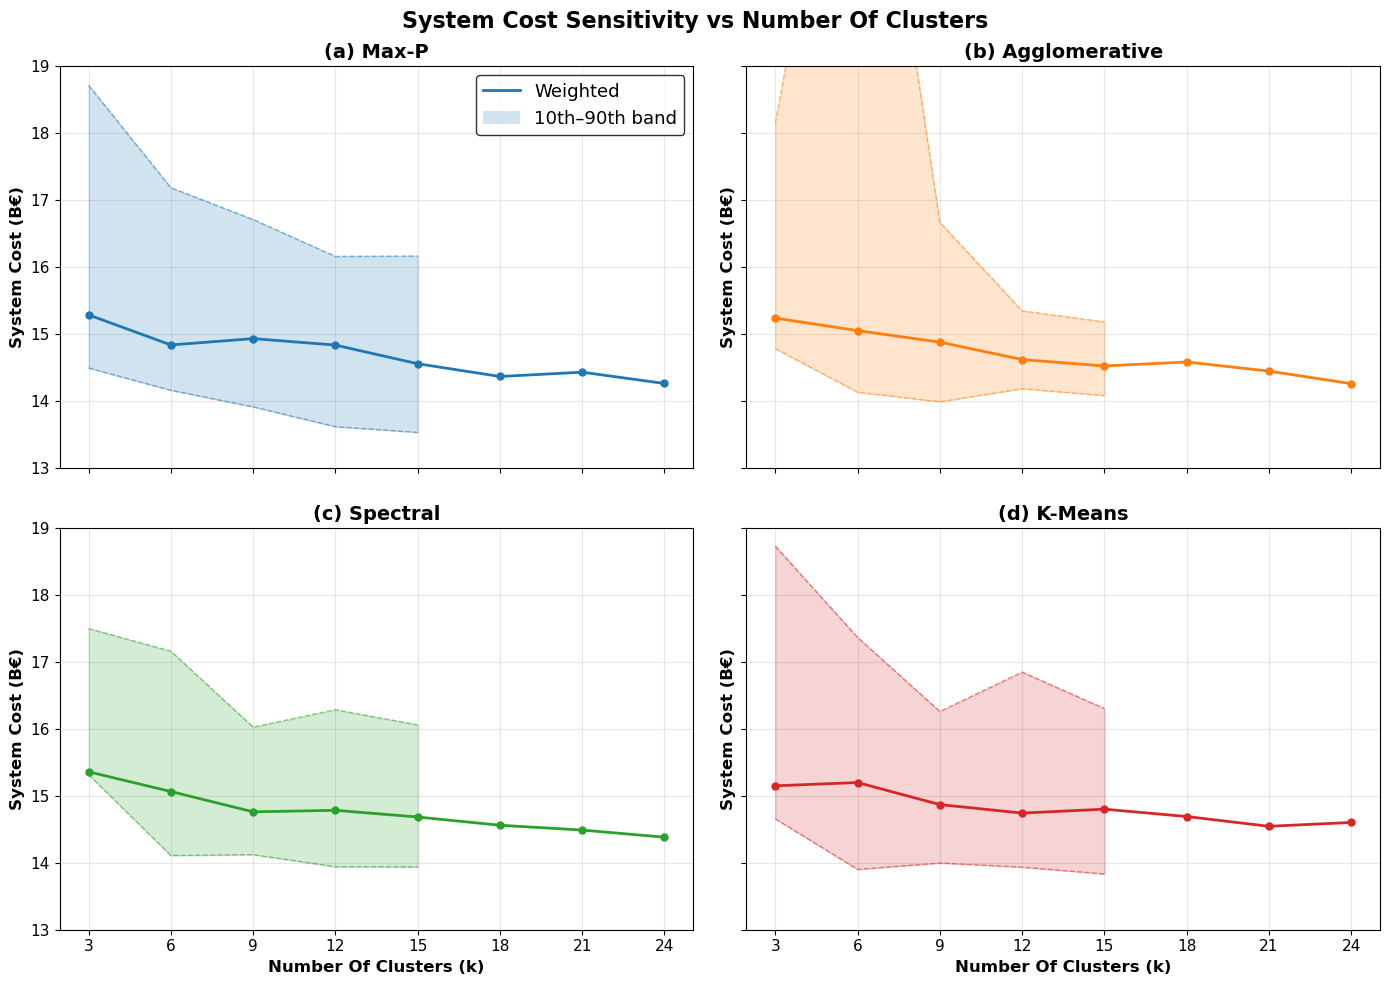

In [2]:
import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── Config ──
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods  = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks_main  = [3, 6, 9, 12, 15, 18, 21, 24]
ks_sens  = [3, 6, 9, 12, 15]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means'}

# ── Load costs ──
weighted_costs = {m: {} for m in methods}
costs_10th     = {m: {} for m in methods}
costs_90th     = {m: {} for m in methods}

for method in methods:
    for k in ks_main:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(path):
            continue
        model = calliope.read_netcdf(path)
        weighted_costs[method][k] = float(model.results.cost.sum()) / 1e6  # B€
        del model; gc.collect()

    for k in ks_sens:
        path_10 = f"{base_dir}/{method}/{method}_k{k}/10_percentile_timeseries/{method}_k{k}_10th_bidirectional.nc"
        path_90 = f"{base_dir}/{method}/{method}_k{k}/90_percentile_timeseries/{method}_k{k}_90th_bidirectional.nc"
        if os.path.exists(path_10):
            model = calliope.read_netcdf(path_10)
            costs_10th[method][k] = float(model.results.cost.sum()) / 1e6
            del model; gc.collect()
        if os.path.exists(path_90):
            model = calliope.read_netcdf(path_90)
            costs_90th[method][k] = float(model.results.cost.sum()) / 1e6
            del model; gc.collect()

# ── Figure ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

panel_config = [
    (axes[0, 0], 'MaxP_Rook',      '(a) Max-P'),
    (axes[0, 1], 'Agglomerative',  '(b) Agglomerative'),
    (axes[1, 0], 'Spectral',       '(c) Spectral'),
    (axes[1, 1], 'KMeans_Spatial', '(d) K-Means'),
]

for ax, method, title in panel_config:
    colour = colours[method]

    # Weighted main line
    w_ks   = sorted(weighted_costs[method].keys())
    w_vals = [weighted_costs[method][k] for k in w_ks]
    ax.plot(w_ks, w_vals, marker='o', markersize=5, linewidth=2, color=colour, zorder=3)

    # Sensitivity band
    s_ks = sorted(set(costs_10th[method].keys()) & set(costs_90th[method].keys()))
    if s_ks:
        lo = [costs_10th[method][k] for k in s_ks]
        hi = [costs_90th[method][k] for k in s_ks]
        ax.fill_between(s_ks, lo, hi, color=colour, alpha=0.2)
        ax.plot(s_ks, lo, linestyle='--', linewidth=1.0, alpha=0.5, color=colour)
        ax.plot(s_ks, hi, linestyle='--', linewidth=1.0, alpha=0.5, color=colour)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('System Cost (B€)', fontweight='bold', fontsize=12)
    ax.set_ylim(13, 19)
    ax.set_xticks(ks_main)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=11)

for ax in axes[1, :]:
    ax.set_xlabel('Number Of Clusters (k)', fontweight='bold', fontsize=12)

# ── Legend on (a) only ──
colour_a = colours['MaxP_Rook']
legend_handles = [
    Line2D([0], [0], color=colour_a, linewidth=2, label='Weighted'),
    Patch(facecolor=colour_a, alpha=0.2, label='10th–90th band'),
]
leg = axes[0, 0].legend(handles=legend_handles, fontsize=13)
leg.get_frame().set_edgecolor('black')

for ax, method, _ in panel_config[1:]:
    ax.legend().remove()

fig.suptitle('System Cost Sensitivity vs Number Of Clusters', fontsize=16, fontweight='bold')
plt.tight_layout(h_pad=2, w_pad=2)
plt.savefig('4YP_Figures/system_cost_2x2_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()

C:\Users\Benhd\AppData\Local\Temp\ipykernel_26700\4091847900.py:89: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



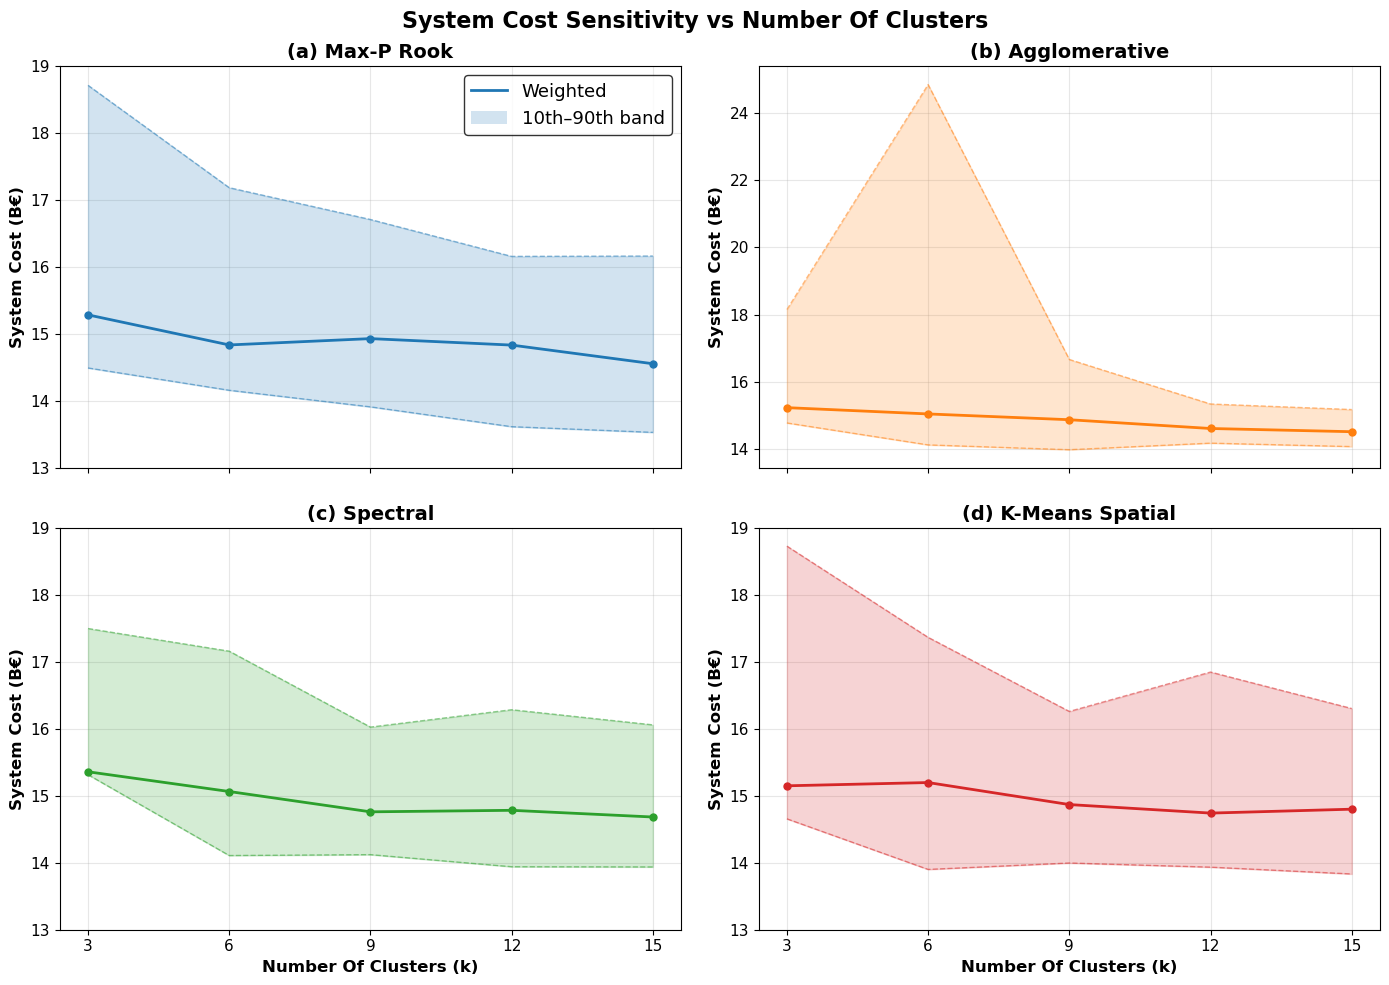

In [3]:
import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── Config ──
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods  = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks_main  = [3, 6, 9, 12, 15]
ks_sens  = [3, 6, 9, 12, 15]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means'}

# ── Load costs ──
weighted_costs = {m: {} for m in methods}
costs_10th     = {m: {} for m in methods}
costs_90th     = {m: {} for m in methods}

for method in methods:
    for k in ks_main:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(path):
            continue
        model = calliope.read_netcdf(path)
        weighted_costs[method][k] = float(model.results.cost.sum()) / 1e6  # B€
        del model; gc.collect()

    for k in ks_sens:
        path_10 = f"{base_dir}/{method}/{method}_k{k}/10_percentile_timeseries/{method}_k{k}_10th_bidirectional.nc"
        path_90 = f"{base_dir}/{method}/{method}_k{k}/90_percentile_timeseries/{method}_k{k}_90th_bidirectional.nc"
        if os.path.exists(path_10):
            model = calliope.read_netcdf(path_10)
            costs_10th[method][k] = float(model.results.cost.sum()) / 1e6
            del model; gc.collect()
        if os.path.exists(path_90):
            model = calliope.read_netcdf(path_90)
            costs_90th[method][k] = float(model.results.cost.sum()) / 1e6
            del model; gc.collect()

# ── Figure ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

panel_config = [
    (axes[0, 0], 'MaxP_Rook',      '(a) Max-P',      True),
    (axes[0, 1], 'Agglomerative',  '(b) Agglomerative',   False),
    (axes[1, 0], 'Spectral',       '(c) Spectral',         True),
    (axes[1, 1], 'KMeans_Spatial', '(d) K-Means',  True),
]

for ax, method, title, fixed_ylim in panel_config:
    colour = colours[method]

    # Weighted main line
    w_ks   = sorted(weighted_costs[method].keys())
    w_vals = [weighted_costs[method][k] for k in w_ks]
    ax.plot(w_ks, w_vals, marker='o', markersize=5, linewidth=2, color=colour, zorder=3)

    # Sensitivity band
    s_ks = sorted(set(costs_10th[method].keys()) & set(costs_90th[method].keys()))
    if s_ks:
        lo = [costs_10th[method][k] for k in s_ks]
        hi = [costs_90th[method][k] for k in s_ks]
        ax.fill_between(s_ks, lo, hi, color=colour, alpha=0.2)
        ax.plot(s_ks, lo, linestyle='--', linewidth=1.0, alpha=0.5, color=colour)
        ax.plot(s_ks, hi, linestyle='--', linewidth=1.0, alpha=0.5, color=colour)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('System Cost (B€)', fontweight='bold', fontsize=12)
    if fixed_ylim:
        ax.set_ylim(13, 19)
    ax.set_xticks(ks_main)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=11)

for ax in axes[1, :]:
    ax.set_xlabel('Number Of Clusters (k)', fontweight='bold', fontsize=12)

# ── Legend on (a) only ──
colour_a = colours['MaxP_Rook']
legend_handles = [
    Line2D([0], [0], color=colour_a, linewidth=2, label='Weighted'),
    Patch(facecolor=colour_a, alpha=0.2, label='10th–90th band'),
]
leg = axes[0, 0].legend(handles=legend_handles, fontsize=13)
leg.get_frame().set_edgecolor('black')

for ax, method, _, __ in panel_config[1:]:
    ax.legend().remove()

fig.suptitle('System Cost Sensitivity vs Number Of Clusters', fontsize=16, fontweight='bold')
plt.tight_layout(h_pad=2, w_pad=2)
plt.savefig('4YP_Figures/system_cost_2x2_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()

C:\Users\Benhd\AppData\Local\Temp\ipykernel_26700\3544102826.py:91: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



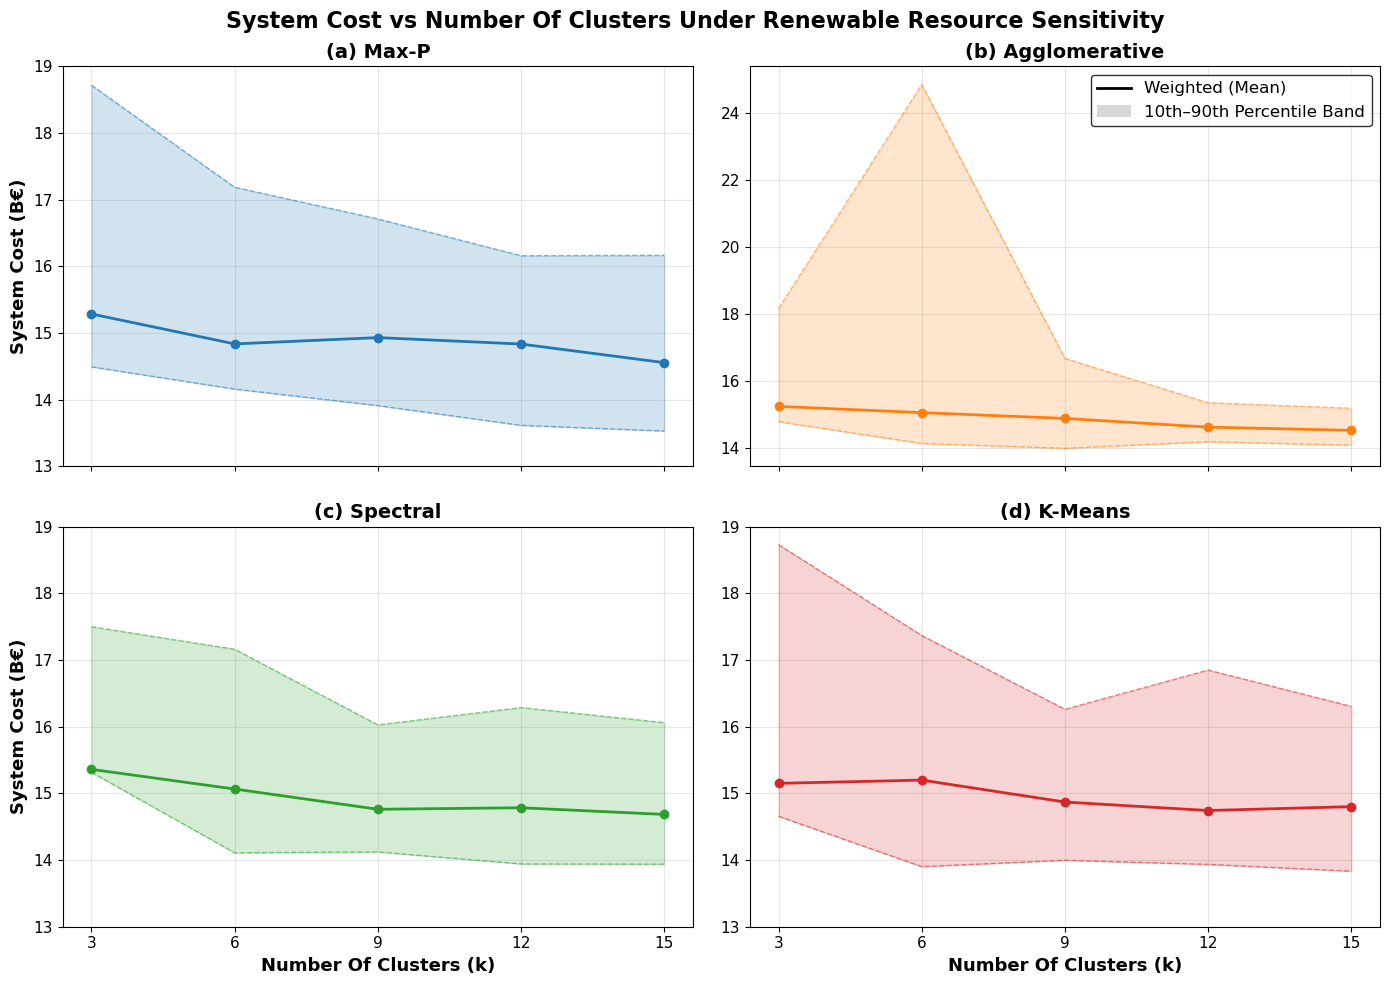

In [11]:
import os, gc, calliope, pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── Config ──
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods  = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks_main  = [3, 6, 9, 12, 15]
ks_sens  = [3, 6, 9, 12, 15]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means'}

# ── Load costs ──
weighted_costs = {m: {} for m in methods}
costs_10th     = {m: {} for m in methods}
costs_90th     = {m: {} for m in methods}

for method in methods:
    for k in ks_main:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(path):
            continue
        model = calliope.read_netcdf(path)
        weighted_costs[method][k] = float(model.results.cost.sum()) / 1e6  # B€
        del model; gc.collect()

    for k in ks_sens:
        path_10 = f"{base_dir}/{method}/{method}_k{k}/10_percentile_timeseries/{method}_k{k}_10th_bidirectional.nc"
        path_90 = f"{base_dir}/{method}/{method}_k{k}/90_percentile_timeseries/{method}_k{k}_90th_bidirectional.nc"
        if os.path.exists(path_10):
            model = calliope.read_netcdf(path_10)
            costs_10th[method][k] = float(model.results.cost.sum()) / 1e6
            del model; gc.collect()
        if os.path.exists(path_90):
            model = calliope.read_netcdf(path_90)
            costs_90th[method][k] = float(model.results.cost.sum()) / 1e6
            del model; gc.collect()

# ── Figure ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

#                  ax            method           title                  fixed_ylim  show_ylabel
panel_config = [
    (axes[0, 0], 'MaxP_Rook',      '(a) Max-P',      True,  True),
    (axes[0, 1], 'Agglomerative',  '(b) Agglomerative',   False, False),
    (axes[1, 0], 'Spectral',       '(c) Spectral',         True,  True),
    (axes[1, 1], 'KMeans_Spatial', '(d) K-Means',  True,  False),
]

for ax, method, title, fixed_ylim, show_ylabel in panel_config:
    colour = colours[method]

    # Weighted main line
    w_ks   = sorted(weighted_costs[method].keys())
    w_vals = [weighted_costs[method][k] for k in w_ks]
    ax.plot(w_ks, w_vals, marker='o', markersize=6, linewidth=2, color=colour, zorder=3)

    # Sensitivity band
    s_ks = sorted(set(costs_10th[method].keys()) & set(costs_90th[method].keys()))
    if s_ks:
        lo = [costs_10th[method][k] for k in s_ks]
        hi = [costs_90th[method][k] for k in s_ks]
        ax.fill_between(s_ks, lo, hi, color=colour, alpha=0.2)
        ax.plot(s_ks, lo, linestyle='--', linewidth=1.0, alpha=0.5, color=colour)
        ax.plot(s_ks, hi, linestyle='--', linewidth=1.0, alpha=0.5, color=colour)

    ax.set_title(title, fontsize=14, fontweight='bold')
    if show_ylabel:
        ax.set_ylabel('System Cost (B€)', fontweight='bold', fontsize=13)
    if fixed_ylim:
        ax.set_ylim(13, 19)
    ax.set_xticks(ks_main)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=11)

for ax in axes[1, :]:
    ax.set_xlabel('Number Of Clusters (k)', fontweight='bold', fontsize=13)

# ── Single encoding legend in Agglomerative panel (top-right) ──
legend_handles = [
    Line2D([0], [0], color='black', linewidth=2, label='Weighted (Mean)'),
    Patch(facecolor='grey', alpha=0.3, label='10th–90th Percentile Band'),
]
leg = axes[0, 1].legend(handles=legend_handles, fontsize=12)
leg.get_frame().set_edgecolor('black')

for ax, _, __, ___, ____ in panel_config:
    if ax is not axes[0, 1]:
        ax.legend().remove()

fig.suptitle('System Cost vs Number Of Clusters Under Renewable Resource Sensitivity', fontsize=16, fontweight='bold')
plt.tight_layout(h_pad=2, w_pad=2)
plt.savefig('4YP_Figures/system_cost_2x2_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()

In [12]:
import calliope

paths = {
    '90th (original)': 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/Spectral/Spectral_k3/90_percentile_timeseries/Spectral_k3_90th_bidirectional.nc',
    '90th (rerun)':    'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/Spectral/Spectral_k3/90_percentile_timeseries/Spectral_90_k3_bidirectional_rerun.nc',
    'Weighted':        'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/Spectral/Spectral_k3/weighted_percentile_timeseries/Spectral_weighted_k3_bidirectional.nc',
}

for label, path in paths.items():
    model = calliope.read_netcdf(path)
    cost_be = float(model.results.cost.sum()) / 1e6
    print(f"{label:20s}  {cost_be:.4f} B€")
    del model

90th (original)       15.3159 B€
90th (rerun)          15.3159 B€
Weighted              15.3595 B€
